Title: LEE_Results_Analysis_all_condensed.ipynb

Purpose: Look at the found LEE Events for current and future climate

Author: Onno Nennecke on 16.07.2025 Modified: 20.04.2026

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:

- Plots
    - These files lie here: /home/onennecke/Code/Figures/

In [4]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

import seaborn as sns

from scipy import stats
from scipy.stats import genextreme, genpareto, ks_2samp, norm


In [5]:
# Function to add a winter season column
def add_winter_season_column(df):
    # Ensure 'date_start' is in datetime format
    df['date_start'] = pd.to_datetime(df['date_start'])
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    
    # Apply the function to create a new 'winter_season' column
    df['winter_season'] = df['date_start'].apply(get_winter_season)
    
    df['season_year'] = df['winter_season'].apply(lambda x: int(x.split('/')[0])) + 2000
    
    return df

### Read LEE data

In [6]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')
LEE_dat = add_winter_season_column(LEE_dat)

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')
LEE_7 = add_winter_season_column(LEE_7)

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')
LEE_14 = add_winter_season_column(LEE_14)

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')
LEE_vl = add_winter_season_column(LEE_vl)

# Read the LEE data
LEE_dat_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_fut.csv')
LEE_dat_fut = add_winter_season_column(LEE_dat_fut)

LEE_dat_7_all_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_fut.csv')
LEE_7_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_fut.csv')
LEE_7_fut = add_winter_season_column(LEE_7_fut)

LEE_dat_14_all_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_fut.csv')
LEE_14_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_fut.csv')
LEE_14_fut = add_winter_season_column(LEE_14_fut)

LEE_vl_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_fut.csv')
LEE_vl_fut = add_winter_season_column(LEE_vl_fut)


LEE_dat_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_ERA5_1960_.csv')
LEE_dat_ERA5_1960_ = add_winter_season_column(LEE_dat_ERA5_1960_)
LEE_dat_7_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_ERA5_1960_.csv')
LEE_dat_7_ERA5_1960_ = add_winter_season_column(LEE_dat_7_ERA5_1960_)
LEE_dat_14_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_ERA5_1960_.csv')
LEE_dat_14_ERA5_1960_ = add_winter_season_column(LEE_dat_14_ERA5_1960_)
LEE_vl_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_ERA5_1960_.csv')
LEE_vl_ERA5_1960_ = add_winter_season_column(LEE_vl_ERA5_1960_)


# ERA5 data
LEE_dat_ERA5_15_24 = LEE_dat[LEE_dat['ESM'] == 'ERA5_week']
LEE_7_ERA5_15_24 = LEE_7[LEE_7['ESM'] == 'ERA5_week']
LEE_14_ERA5_15_24 = LEE_14[LEE_14['ESM'] == 'ERA5_week']
LEE_vl_ERA5_15_24 = LEE_vl[LEE_vl['ESM'] == 'ERA5_week']

In [7]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd') & (LEE_dat['ESM'] != 'ERA5_week')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd') & (LEE_7['ESM'] != 'ERA5_week')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd') & (LEE_14['ESM'] != 'ERA5_week')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd') & (LEE_vl['ESM'] != 'ERA5_week')]

In [8]:
'''# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd') & (LEE_dat['ESM'] != 'ERA5_week')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd') & (LEE_7['ESM'] != 'ERA5_week')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd') & (LEE_14['ESM'] != 'ERA5_week')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd') & (LEE_vl['ESM'] != 'ERA5_week')]
# Put the other ERA5 data into the LEE_dat DataFrame
LEE_dat = pd.concat([LEE_dat, LEE_dat_ERA5_1960_], ignore_index=True)
LEE_7 = pd.concat([LEE_7, LEE_dat_7_ERA5_1960_], ignore_index=True)
LEE_14 = pd.concat([LEE_14, LEE_dat_14_ERA5_1960_], ignore_index=True)
LEE_vl = pd.concat([LEE_vl, LEE_vl_ERA5_1960_], ignore_index=True)'''


"# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame\nLEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd') & (LEE_dat['ESM'] != 'ERA5_week')]\nLEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd') & (LEE_7['ESM'] != 'ERA5_week')]\nLEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd') & (LEE_14['ESM'] != 'ERA5_week')]\nLEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd') & (LEE_vl['ESM'] != 'ERA5_week')]\n# Put the other ERA5 data into the LEE_dat DataFrame\nLEE_dat = pd.concat([LEE_dat, LEE_dat_ERA5_1960_], ignore_index=True)\nLEE_7 = pd.concat([LEE_7, LEE_dat_7_ERA5_1960_], ignore_index=True)\nLEE_14 = pd.concat([LEE_14, LEE_dat_14_ERA5_1960_], ignore_index=True)\nLEE_vl = pd.concat([LEE_vl, LEE_vl_ERA5_1960_], ignore_index=True)"

## Compare and quantify most extreme events for different datasources

In [9]:
def compare_extremes(CMIP, ERA5_15_24, ERA5_1960):
    CMIP_max = CMIP['RL_cumulative'].max()
    ERA5_1960_max = ERA5_1960['RL_cumulative'].max()
    ERA5_15_24_max = ERA5_15_24['RL_cumulative'].max()

    print(f"CMIP max: {CMIP_max}")
    print(f"ERA5_1960 max: {ERA5_1960_max}")
    print(f"ERA5_15_24 max: {ERA5_15_24_max}")

    # Calculate the percent difference between the maximum values of CMIP and ERA5_1960, and CMIP and ERA5_15_24
    percent_diff_CMIP_ERA5_1960 = ((CMIP_max - ERA5_1960_max) / CMIP_max) * 100
    percent_diff_CMIP_ERA5_15_24 = ((CMIP_max - ERA5_15_24_max) / CMIP_max) * 100

    print(f"Percent difference between CMIP and ERA5_1960: {percent_diff_CMIP_ERA5_1960}%")
    print(f"Percent difference between CMIP and ERA5_15_24: {percent_diff_CMIP_ERA5_15_24}%")

    return None

In [10]:
compare_extremes(LEE_dat, LEE_dat_ERA5_15_24, LEE_dat_ERA5_1960_)

compare_extremes(LEE_7, LEE_7_ERA5_15_24, LEE_dat_7_ERA5_1960_)

compare_extremes(LEE_14, LEE_14_ERA5_15_24, LEE_dat_14_ERA5_1960_)

CMIP max: 1583.1053720383402
ERA5_1960 max: 1589.5272153175442
ERA5_15_24 max: 1486.4413871898555
Percent difference between CMIP and ERA5_1960: -0.4056485053130446%
Percent difference between CMIP and ERA5_15_24: 6.105972890738422%
CMIP max: 10850.4307223188
ERA5_1960 max: 10216.630309809476
ERA5_15_24 max: 9892.719663878142
Percent difference between CMIP and ERA5_1960: 5.841246571029006%
Percent difference between CMIP and ERA5_15_24: 8.826479638920635%
CMIP max: 20911.380672958014
ERA5_1960 max: 19306.070388266533
ERA5_15_24 max: 18727.325162984856
Percent difference between CMIP and ERA5_1960: 7.676730244633828%
Percent difference between CMIP and ERA5_15_24: 10.444339109552503%


---

### Count

In [11]:
# Pure CMIP6 data
LEE_dat_CMIP = LEE_dat[LEE_dat['ESM'] != 'ERA5_week']
LEE_7_CMIP = LEE_7[LEE_7['ESM'] != 'ERA5_week']
LEE_14_CMIP = LEE_14[LEE_14['ESM'] != 'ERA5_week']
LEE_vl_CMIP = LEE_vl[LEE_vl['ESM'] != 'ERA5_week']

In [12]:
# Pure ERA5 data
# LEE_dat_ERA5 = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')]
# LEE_7_ERA5 = LEE_7[(LEE_7['ESM'] == 'ERA5_week')]
# LEE_14_ERA5 = LEE_14[(LEE_14['ESM'] == 'ERA5_week')]
# LEE_vl_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')]
LEE_dat_ERA5 = LEE_dat_ERA5_1960_
LEE_7_ERA5 = LEE_dat_7_ERA5_1960_
LEE_14_ERA5 = LEE_dat_14_ERA5_1960_
LEE_vl_ERA5 = LEE_vl_ERA5_1960_


In [13]:
LEE_dat_ERA5_1960_

LEE_dat_ERA5_1960_1990 = LEE_dat_ERA5_1960_[LEE_dat_ERA5_1960_['date_start'] < '1990-01-01']
LEE_dat_ERA5_1990_2024 = LEE_dat_ERA5_1960_[LEE_dat_ERA5_1960_['date_start'] >= '1990-01-01']

In [14]:
max(LEE_vl_ERA5['RL_mean'])
max(LEE_dat_ERA5['RL_mean'])

1589.5272153175442

In [15]:
max(LEE_dat_CMIP['RL_mean'])
LEE_dat_CMIP[LEE_dat_CMIP['RL_mean'] == max(LEE_dat_CMIP['RL_mean'])]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season,season_year
24639,2019-12-16,2019-12-16,2019-12-16,1809,1809,1809,1,1583.105372,1583.105372,0.0,1583.105372,24640,EC-Earth3,EC-Earth3_r121i1p1f1,2019,350,19/20,2019


### Check how the LEE Days are distributed over the modells

In [16]:
'''# Add number of runs to the DataFrame
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl['Nr_of_years'] = LEE_vl['Nr_of_runs'] * 10
# Replace the value for ERA5_week with 1 in the Nr_of_runs column
LEE_vl.loc[LEE_vl['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 1
LEE_vl.loc[LEE_vl['ESM'] == 'ERA5_week', 'Nr_of_years'] = 65

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
# LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values
# Add a CMIP6 row (Exclude ERA5) for total duration across all ESMs
cmip6_duration = LEE_all_comp[LEE_all_comp['ESM'] != 'ERA5_week']['LEE_vl_dur_sum'].sum()
cmip6_nr_of_runs = LEE_all_comp[LEE_all_comp['ESM'] != 'ERA5_week']['Nr_of_runs'].sum()
cmip6_row = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_vl_dur_sum': [cmip6_duration], 'Nr_of_runs': [cmip6_nr_of_runs], 'Nr_of_years': [cmip6_nr_of_runs * 10]})
LEE_all_comp = pd.concat([LEE_all_comp, cmip6_row], ignore_index=True)

LEE_all_comp['LEE_vl_dur_avg'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_vl_dur_avg_ranking'] = LEE_all_comp['LEE_vl_dur_avg'].rank(ascending=False)
# Remove most of the columns except for the ones we want to keep
LEE_all_comp = LEE_all_comp[['ESM', 'Nr_of_runs', 'Nr_of_years', 'LEE_vl_dur_sum', 'LEE_vl_dur_avg', 'LEE_vl_dur_avg_ranking']]


# LEE_dat_temp = LEE_dat.copy()
# LEE_dat_temp['LEE_dat_dur_sum'] = LEE_dat_temp.groupby('ESM')['duration'].transform('sum')
# LEE_dat_temp = LEE_dat_temp.drop_duplicates(subset=['ESM', 'LEE_dat_dur_sum'])
# LEE_dat_temp
# Join the two DataFrames on 'ESM'
# LEE_all_comp = LEE_all_comp.merge(LEE_dat_temp[['ESM', 'LEE_dat_dur_sum']], on='ESM', how='left')
# LEE_all_comp['LEE_dat_dur_avg'] = LEE_all_comp['LEE_dat_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp

LEE_7_temp = LEE_7.copy()
LEE_7_temp['LEE_7_dur_sum'] = LEE_7_temp.groupby('ESM')['duration'].transform('sum')
LEE_7_temp = LEE_7_temp.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])
cmip6_duration_7 = LEE_7_temp[LEE_7_temp['ESM'] != 'ERA5_week']['LEE_7_dur_sum'].sum()
cmip6_nr_of_runs_7 = LEE_7_temp[LEE_7_temp['ESM'] != 'ERA5_week']['ESM_run'].nunique()
cmip6_row_7 = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_7_dur_sum': [cmip6_duration_7], 'Nr_of_runs': [cmip6_nr_of_runs_7], 'Nr_of_years': [cmip6_nr_of_runs_7 * 10]})
LEE_7_temp = pd.concat([LEE_7_temp, cmip6_row_7], ignore_index=True)
LEE_7_temp

# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_7_temp[['ESM', 'LEE_7_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_7_dur_avg'] = LEE_all_comp['LEE_7_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_7_dur_avg_ranking'] = LEE_all_comp['LEE_7_dur_avg'].rank(ascending=False)

LEE_14_temp = LEE_14.copy()
LEE_14_temp['LEE_14_dur_sum'] = LEE_14_temp.groupby('ESM')['duration'].transform('sum')
LEE_14_temp = LEE_14_temp.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])
cmip6_duration_14 = LEE_14_temp[LEE_14_temp['ESM'] != 'ERA5_week']['LEE_14_dur_sum'].sum()
cmip6_nr_of_runs_14 = LEE_14_temp[LEE_14_temp['ESM'] != 'ERA5_week']['ESM_run'].nunique()
cmip6_row_14 = pd.DataFrame({'ESM': ['CMIP6 Average'], 'LEE_14_dur_sum': [cmip6_duration_14], 'Nr_of_runs': [cmip6_nr_of_runs_14], 'Nr_of_years': [cmip6_nr_of_runs_14 * 10]})
LEE_14_temp = pd.concat([LEE_14_temp, cmip6_row_14], ignore_index=True)
LEE_14_temp
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_14_temp[['ESM', 'LEE_14_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_14_dur_avg'] = LEE_all_comp['LEE_14_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp['LEE_14_dur_avg_ranking'] = LEE_all_comp['LEE_14_dur_avg'].rank(ascending=False)

LEE_all_comp['ESM_label'] = LEE_all_comp['ESM'] + ' \n (n = ' + LEE_all_comp['Nr_of_years'].astype(str) + ')'
# Fix the label for ERA5_week to display as "ERA5 \n (n = 1)"
# LEE_all_comp.loc[LEE_all_comp['ESM'] == 'ERA5_week', 'ESM_label'] = 'ERA5 \n (n = 1)'
LEE_all_comp
'''

'# Add number of runs to the DataFrame\nNr_of_runs = LEE_vl.groupby(\'ESM\')[\'ESM_run\'].nunique()\nLEE_vl[\'Nr_of_runs\'] = LEE_vl[\'ESM\'].map(Nr_of_runs)\nLEE_vl[\'Nr_of_years\'] = LEE_vl[\'Nr_of_runs\'] * 10\n# Replace the value for ERA5_week with 1 in the Nr_of_runs column\nLEE_vl.loc[LEE_vl[\'ESM\'] == \'ERA5_week\', \'Nr_of_runs\'] = 1\nLEE_vl.loc[LEE_vl[\'ESM\'] == \'ERA5_week\', \'Nr_of_years\'] = 65\n\nLEE_all_comp = LEE_vl.copy()\n\n\nLEE_all_comp[\'LEE_vl_dur_sum\'] = LEE_all_comp.groupby(\'ESM\')[\'duration\'].transform(\'sum\')\nLEE_all_comp = LEE_all_comp.drop_duplicates(subset=[\'ESM\', \'LEE_vl_dur_sum\'])\n# LEE_all_comp[\'Nr_of_runs\'] = Nr_of_runs.values\n# Add a CMIP6 row (Exclude ERA5) for total duration across all ESMs\ncmip6_duration = LEE_all_comp[LEE_all_comp[\'ESM\'] != \'ERA5_week\'][\'LEE_vl_dur_sum\'].sum()\ncmip6_nr_of_runs = LEE_all_comp[LEE_all_comp[\'ESM\'] != \'ERA5_week\'][\'Nr_of_runs\'].sum()\ncmip6_row = pd.DataFrame({\'ESM\': [\'CMIP6 Average\']

In [17]:
print(252.105263 / 99 * 100)
print(124.157895 / 49 * 100)
print(84.000000 / 9.3 * 100)

254.65178080808082
253.38345918367344
903.2258064516128


In [18]:
# ---- 7 -------------------------------------------------
Nr = LEE_7.groupby('ESM')['ESM_run'].nunique()
df = LEE_7.copy()
df['Nr_of_runs'] = df['ESM'].map(Nr)

df['Nr_of_years'] = df['Nr_of_runs'] * 10

df['LEE_7_dur_sum'] = df.groupby('ESM')['duration'].transform('sum')
df = df.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])

std_values = {esm: np.std(LEE_7[LEE_7['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in LEE_7['ESM'].unique()}
df['LEE_7_dur_std'] = df['ESM'].map(std_values)

cmip = df[df['ESM'] != 'ERA5_week']
df = pd.concat([
    df,
    pd.DataFrame({
        'ESM': ["CMIP6 Average"],
        'LEE_7_dur_sum': [cmip['LEE_7_dur_sum'].sum()],
        'Nr_of_runs': [cmip['Nr_of_runs'].sum()],
        'Nr_of_years': [cmip['Nr_of_runs'].sum() * 10],
        'LEE_7_dur_std': [np.std(LEE_7.groupby('ESM_run')['duration'].sum())] # ???
    }),
    pd.DataFrame({
        'ESM': ["CMIP6 Average (weighted)"],
        'LEE_7_dur_sum': [(cmip['LEE_7_dur_sum'] / cmip['Nr_of_runs']).sum()],
        'Nr_of_runs': [10],
        'Nr_of_years': [100],
        'LEE_7_dur_std': [np.std((cmip['LEE_7_dur_sum'] / cmip['Nr_of_runs']))]
    })
])

df['LEE_7_dur_avg'] = df['LEE_7_dur_sum'] / df['Nr_of_runs']

In [19]:
# ============================================================
# --------- BUILD HISTORICAL COMPOSITE (VL / 7 / 14) ----------
# ============================================================

def build_comp(LEE_vl, LEE_7, LEE_14, label_cmip="CMIP6 Average", ERA5 = False):
    # ---- VL -------------------------------------------------
    Nr = LEE_vl.groupby('ESM')['ESM_run'].nunique()
    df = LEE_vl.copy()
    df['Nr_of_runs'] = df['ESM'].map(Nr)
    if ERA5:
        df.loc[df['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
    df['Nr_of_years'] = df['Nr_of_runs'] * 10

    df['LEE_vl_dur_sum'] = df.groupby('ESM')['duration'].transform('sum')
    df = df.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])

    std_values = {esm: np.std(LEE_vl[LEE_vl['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in LEE_vl['ESM'].unique()}
    df['LEE_vl_dur_std'] = df['ESM'].map(std_values)

    cmip = df[df['ESM'] != 'ERA5_week']
    df = pd.concat([
        df,
        pd.DataFrame({
            'ESM': [label_cmip],
            'LEE_vl_dur_sum': [cmip['LEE_vl_dur_sum'].sum()],
            'Nr_of_runs': [cmip['Nr_of_runs'].sum()],
            'Nr_of_years': [cmip['Nr_of_runs'].sum() * 10],
            'LEE_vl_dur_std': [np.std(LEE_vl.groupby('ESM_run')['duration'].sum())]
        }),
        pd.DataFrame({
            'ESM': ["CMIP6 Average (weighted)"],
            'LEE_vl_dur_sum': [(cmip['LEE_vl_dur_sum'] / cmip['Nr_of_runs']).sum()],
            'Nr_of_runs': [10],
            'Nr_of_years': [100],
            'LEE_vl_dur_std': [np.std((cmip['LEE_vl_dur_sum'] / cmip['Nr_of_runs']))]
        })
    ])

    df['LEE_vl_dur_avg'] = df['LEE_vl_dur_sum'] / df['Nr_of_runs']


    # ---- 7 -------------------------------------------------
    Nr = LEE_7.groupby('ESM')['ESM_run'].nunique()
    df_7 = LEE_7.copy()
    df_7['Nr_of_runs'] = df_7['ESM'].map(Nr)
    if ERA5:
        df_7.loc[df_7['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
    df_7['Nr_of_years'] = df_7['Nr_of_runs'] * 10

    df_7['LEE_7_dur_sum'] = df_7.groupby('ESM')['duration'].transform('sum')
    df_7 = df_7.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])

    std_values = {esm: np.std(LEE_7[LEE_7['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in LEE_7['ESM'].unique()}
    df_7['LEE_7_dur_std'] = df_7['ESM'].map(std_values)

    cmip = df_7[df_7['ESM'] != 'ERA5_week']
    df_7 = pd.concat([
        df_7,
        pd.DataFrame({
            'ESM': ["CMIP6 Average"],
            'LEE_7_dur_sum': [cmip['LEE_7_dur_sum'].sum()],
            'Nr_of_runs': [cmip['Nr_of_runs'].sum()],
            'Nr_of_years': [cmip['Nr_of_runs'].sum() * 10],
            'LEE_7_dur_std': [np.std(LEE_7.groupby('ESM_run')['duration'].sum())] # ???
        }),
        pd.DataFrame({
            'ESM': ["CMIP6 Average (weighted)"],
            'LEE_7_dur_sum': [(cmip['LEE_7_dur_sum'] / cmip['Nr_of_runs']).sum()],
            'Nr_of_runs': [10],
            'Nr_of_years': [100],
            'LEE_7_dur_std': [np.std((cmip['LEE_7_dur_sum'] / cmip['Nr_of_runs']))]
        })
    ])

    df_7['LEE_7_dur_avg'] = df_7['LEE_7_dur_sum'] / df_7['Nr_of_runs']

    df = df.merge(df_7[['ESM', 'LEE_7_dur_sum', 'LEE_7_dur_std', 'LEE_7_dur_avg']], on='ESM', how='left')


    # ---- 14 -------------------------------------------------
    Nr = LEE_14.groupby('ESM')['ESM_run'].nunique()
    df_14 = LEE_14.copy()
    df_14['Nr_of_runs'] = df_14['ESM'].map(Nr)
    if ERA5:
        df_14.loc[df_14['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
    df_14['Nr_of_years'] = df_14['Nr_of_runs'] * 10

    df_14['LEE_14_dur_sum'] = df_14.groupby('ESM')['duration'].transform('sum')
    df_14 = df_14.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])

    std_values = {esm: np.std(LEE_14[LEE_14['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in LEE_14['ESM'].unique()}
    df_14['LEE_14_dur_std'] = df_14['ESM'].map(std_values)

    cmip = df_14[df_14['ESM'] != 'ERA5_week']
    df_14 = pd.concat([
        df_14,
        pd.DataFrame({
            'ESM': ["CMIP6 Average"],
            'LEE_14_dur_sum': [cmip['LEE_14_dur_sum'].sum()],
            'Nr_of_runs': [cmip['Nr_of_runs'].sum()],
            'Nr_of_years': [cmip['Nr_of_runs'].sum() * 10],
            'LEE_14_dur_std': [np.std(LEE_14.groupby('ESM_run')['duration'].sum())] # ???
        }),
        pd.DataFrame({
            'ESM': ["CMIP6 Average (weighted)"],
            'LEE_14_dur_sum': [(cmip['LEE_14_dur_sum'] / cmip['Nr_of_runs']).sum()],
            'Nr_of_runs': [10],
            'Nr_of_years': [100],
            'LEE_14_dur_std': [np.std((cmip['LEE_14_dur_sum'] / cmip['Nr_of_runs']))]
        })
    ])

    df_14['LEE_14_dur_avg'] = df_14['LEE_14_dur_sum'] / df_14['Nr_of_runs']


    df = df.merge(df_14[['ESM', 'LEE_14_dur_sum', 'LEE_14_dur_std', 'LEE_14_dur_avg']], on='ESM', how='left')

    # # ---- 7 / 14 ---------------------------------------------
    # for src, tag in [(LEE_7, '7'), (LEE_14, '14')]:
    #     tmp = src.copy()
    #     tmp[f'LEE_{tag}_dur_sum'] = tmp.groupby('ESM')['duration'].transform('sum')
    #     tmp = tmp.drop_duplicates(subset=['ESM', f'LEE_{tag}_dur_sum'])

    #     std_values = {esm: np.std(src[src['ESM'] == esm].groupby('ESM_run')['duration'].sum()) for esm in src['ESM'].unique()}
    #     tmp[f'LEE_{tag}_dur_std'] = tmp['ESM'].map(std_values)

    #     cm = tmp[tmp['ESM'] != 'ERA5_week']
    #     tmp = pd.concat([
    #         tmp,
    #         pd.DataFrame({
    #             'ESM': [label_cmip],
    #             f'LEE_{tag}_dur_sum': [cm[f'LEE_{tag}_dur_sum'].sum()],
    #             f'LEE_{tag}_dur_std': [np.std(src.groupby('ESM_run')['duration'].sum())]
    #         }),
    #         pd.DataFrame({
    #             'ESM': ["CMIP6 Average (weighted)"],
    #             f'LEE_{tag}_dur_sum': [(cm[f'LEE_{tag}_dur_sum'] / cmip['Nr_of_runs']).sum() * 10],
    #             f'LEE_{tag}_dur_std': [np.std((cm[f'LEE_{tag}_dur_sum'] / cmip['Nr_of_runs']))]
    #         })
    #     ])

    #     df = df.merge(tmp[['ESM', f'LEE_{tag}_dur_sum', f'LEE_{tag}_dur_std']], on='ESM', how='left')
    #     df[f'LEE_{tag}_dur_avg'] = df[f'LEE_{tag}_dur_sum'] / df['Nr_of_runs']

    # ---- labels ---------------------------------------------
    df['ESM_label'] = (
        df['ESM'] + '\n(n = ' + df['Nr_of_years'].astype(int).astype(str) + ')'
    )
    # Change label of CMIP average (weighted)
    df.loc[df['ESM'] == 'CMIP6 Average (weighted)', 'ESM_label'] = 'CMIP6 mean\n(one model one vote)\n(n = 1920)'
    
    # df.loc[df['ESM'] == 'ERA5_week', 'ESM_label'] = 'ERA5\n(n = 1)'
    # Remove column date_start
    df = df.drop(columns=['date_start', 'date_end', 'date_peak', 'index_start', 'index_end', 'index_peak', 'duration',
                          'RL_max', 'RL_mean', 'RL_var', 'RL_cumulative', 'event', 'year', 'ESM_run', 'winter_season'])
    
    return df


# historical + future
LEE_hist = build_comp(LEE_vl, LEE_7, LEE_14)
LEE_fut  = build_comp(LEE_vl_fut, LEE_7_fut, LEE_14_fut)

LEE_ERA5_1960 = build_comp(LEE_vl_ERA5_1960_, LEE_dat_7_ERA5_1960_, LEE_dat_14_ERA5_1960_, ERA5=True)
LEE_ERA5_1960.loc[0, 'ESM_label'] = 'ERA5 (1960 - 2024)\n(n = 65)'
LEE_ERA5_15_24 = build_comp(LEE_vl_ERA5_15_24, LEE_7_ERA5_15_24, LEE_14_ERA5_15_24)
LEE_ERA5_15_24.loc[0, 'ESM_label'] = 'ERA5 (2015 - 2024)\n(n = 10)'

# Remove ERA5 from hist and replace it by the 1960-2020 ERA5 composite (since the latter is more robust and consistent with the CMIP6 models)
LEE_hist = LEE_hist[LEE_hist['ESM'] != 'ERA5_week']
LEE_hist = pd.concat([LEE_hist, LEE_ERA5_1960[:1]], ignore_index=True)
LEE_hist = pd.concat([LEE_hist, LEE_ERA5_15_24[:1]], ignore_index=True)
LEE_hist = LEE_hist.drop(columns=['doy'])


/tmp/ipykernel_2017909/45921782.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
/tmp/ipykernel_2017909/45921782.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_7.loc[df_7['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5
/tmp/ipykernel_2017909/45921782.py:85: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_14.loc[df_14['ESM'] == 'ERA5_week', 'Nr_of_runs'] = 6.5


In [20]:
539 / 65

8.292307692307693

In [21]:
LEE_hist

,ESM,season_year,Nr_of_runs,Nr_of_years,LEE_vl_dur_sum,LEE_vl_dur_std,LEE_vl_dur_avg,LEE_7_dur_sum,LEE_7_dur_std,LEE_7_dur_avg,LEE_14_dur_sum,LEE_14_dur_std,LEE_14_dur_avg,ESM_label
0,ACCESS-CM2,2014.0,3.0,30.0,595.000000,15.107026,198.333333,217.000000,16.499158,72.333333,112.000000,28.000000,56.000000,ACCESS-CM2\n(n = 30)
1,BCC-CSM2-MR,2014.0,1.0,10.0,185.000000,0.000000,185.000000,98.000000,0.000000,98.000000,98.000000,0.000000,98.000000,BCC-CSM2-MR\n(n = 10)
2,CESM2,2014.0,103.0,1030.0,21076.000000,35.270967,204.621359,11214.000000,28.849014,108.873786,8106.000000,37.269862,80.257426,CESM2\n(n = 1030)
3,EC-Earth3,2014.0,54.0,540.0,7319.000000,16.163187,135.537037,2478.000000,14.798231,45.888889,574.000000,10.399420,22.076923,EC-Earth3\n(n = 540)
4,GFDL-ESM4,2014.0,1.0,10.0,136.000000,0.000000,136.000000,35.000000,0.000000,35.000000,NaN,NaN,NaN,GFDL-ESM4\n(n = 10)
5,KACE-1-0-G,2014.0,3.0,30.0,298.000000,8.178563,99.333333,140.000000,8.730534,46.666667,42.000000,7.000000,21.000000,KACE-1-0-G\n(n = 30)
6,MPI-ESM1-2-HR,2014.0,10.0,100.0,2185.000000,33.764626,218.500000,973.000000,24.539967,97.300000,504.000000,17.928748,50.400000,MPI-ESM1-2-HR\n(n = 100)
7,MRI-ESM2-0,2014.0,5.0,50.0,706.000000,17.290460,141.200000,308.000000,24.409834,61.600000,140.000000,21.000000,35.000000,MRI-ESM2-0\n(n = 50)
8,TaiESM1,2014.0,1.0,10.0,150.000000,0.000000,150.000000,49.000000,0.000000,49.000000,14.000000,0.000000,14.000000,TaiESM1\n(n = 10)
9,UKESM1-0-LL,2014.0,11.0,110.0,2413.000000,30.639466,219.363636,1085.000000,19.448172,98.636364,518.000000,31.741726,47.090909,UKESM1-0-LL\n(n = 110)


In [22]:
63.41+9.22
print(72.63 * 24)
print(88.83*7)

1743.12
621.81


['CMIP6 Average\n(n = 1920)']
['CMIP6 Average\n(n = 1920)', 'CMIP6 mean\n(one model one vote)\n(n = 1920)', 'ERA5 (2015 - 2024)\n(n = 10)', 'ERA5 (1960 - 2024)\n(n = 65)']


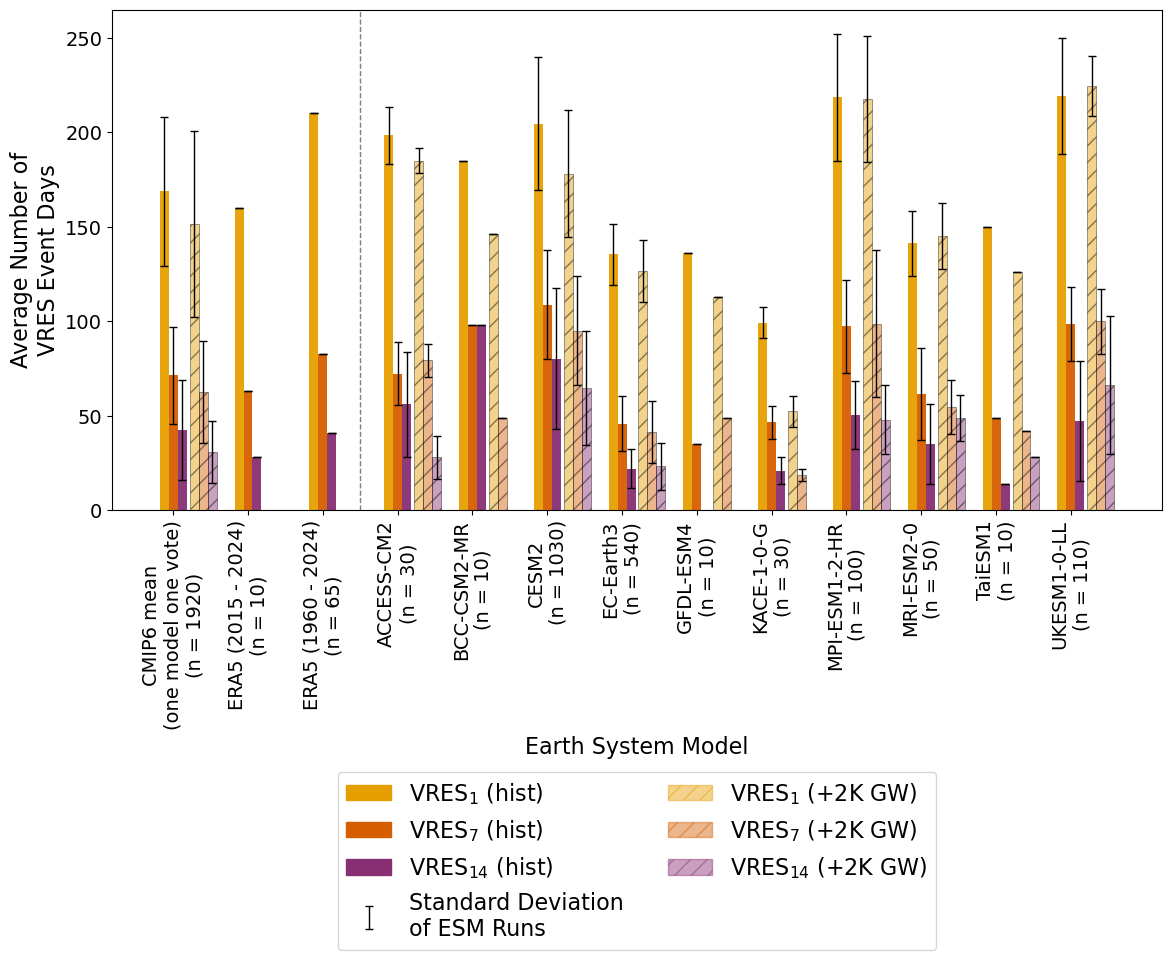

In [23]:

# ============================================================
# ------------------------ PLOTTING --------------------------
# ============================================================

mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})

cols = ['LEE_vl_dur_avg', 'LEE_7_dur_avg', 'LEE_14_dur_avg']
cols_std = ['LEE_vl_dur_std', 'LEE_7_dur_std', 'LEE_14_dur_std']
colors = ['#E69F00', '#D55E00', '#882E72']

# # --- build dataframes --------------------------------------
df_hist = LEE_hist.set_index('ESM_label')[cols]
df_fut  = LEE_fut.set_index('ESM_label')[cols]
df_hist_std = LEE_hist.set_index('ESM_label')[cols_std]
df_fut_std  = LEE_fut.set_index('ESM_label')[cols_std]

# --- ordering (same as original) ---------------------------
# cmip_label = next(l for l in df_hist.index if 'CMIP6' in l)
# order = [cmip_label] + [l for l in df_hist.index if l != cmip_label]

# df_hist = df_hist.loc[order]
# df_fut  = df_fut.reindex(order)   # ERA5 → NaN (no crash)
# --- ordering: CMIP6, then ERA5, then the rest ----------------
cmip_label = next(l for l in df_hist.index if 'CMIP6' in l)
cmip_label_ave = next(l for l in df_hist.index if 'CMIP6 mean' in l)
era_label  = next((l for l in df_hist.index if 'ERA5' in l), None)
era_label_15_24  = next((l for l in df_hist.index if '(2015 - 2024)' in l), None)
# print(cmip_label)
# print(era_label)
order = [cmip_label]
print(order)
if cmip_label_ave is not None:
    order.append(cmip_label_ave)
if era_label_15_24 is not None:
    order.append(era_label_15_24)
if era_label is not None:
    order.append(era_label)
print(order)

order += [l for l in df_hist.index if l not in order]


df_hist = df_hist.loc[order]
df_hist_std = df_hist_std.loc[order]
df_fut  = df_fut.reindex(order)   # ERA5 future stays NaN → fine
df_fut_std  = df_fut_std.reindex(order)

order = order[1:]
df_hist = df_hist[1:]  # Remove the first row (CMIP6 Average) from the historical data
df_hist_std = df_hist_std[1:]  # Remove the first row (CMIP
df_fut = df_fut[1:]  # Remove the first row (CMIP6 Average) from the future data
df_fut_std = df_fut_std[1:]  # Remove the first row (CMIP6 Average) from the future data
# ============================================================
# --------------------- BAR POSITIONS ------------------------
# ============================================================

n_groups = len(order)
x = np.arange(n_groups)

bar_w = 0.12            # individual bar width
group_gap = 0.04        # gap between hist and future triplets

# offsets: 3 hist bars, gap, 3 future bars
offsets_hist = np.array([-1, 0, 1]) * bar_w
offsets_fut  = np.array([2, 3, 4]) * bar_w + group_gap

fig, ax = plt.subplots(figsize=(12, 12))

# --- historical bars ---------------------------------------
for i, col in enumerate(cols):
    ax.bar(
        x + offsets_hist[i],
        df_hist[col].values,
        width=bar_w,
        color=colors[i],
        alpha=0.95,
        label=None
    )
    
    # Add error bars for historical data
    std_col = col.replace('avg', 'std') 
    ax.errorbar(
        x + offsets_hist[i],
        df_hist[col].values,
        yerr=df_hist_std[std_col].values,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1
    )

# --- future bars (hatched, lighter) ------------------------
for i, col in enumerate(cols):
    ax.bar(
        x + offsets_fut[i],
        df_fut[col].values,
        width=bar_w,
        color=colors[i],
        alpha=0.45,
        hatch='//',
        edgecolor='black',
        linewidth=0.6,
        label=None
    )
    
    # Add error bars for future data (if available)
    std_col = col.replace('avg', 'std')
    # print(df_fut[col].values)
    ax.errorbar(
        x + offsets_fut[i],
        df_fut[col].values,
        yerr=df_fut_std[std_col].values,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1
    )
    

# --- separator after CMIP6 ---------------------------------
# ax.axvline(x=0.5, color="#7E7E7E", linestyle='--', linewidth=1)
# --- separator after ERA5 (or after CMIP6 if ERA5 missing) ----
sep_pos = order.index(era_label) if era_label in order else order.index(cmip_label)
ax.axvline(x=sep_pos + 0.5, color="#7E7E7E", linestyle='--', linewidth=1)
# --- axes & labels -----------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=90)
ax.set_ylabel('Average Number of\nVRES Event Days')
ax.set_xlabel('Earth System Model')

# --- legend (same as original, plus note) ------------------
legend_labels = [
    r'$\mathrm{VRES}_{1}$ (hist)',
    r'$\mathrm{VRES}_{7}$ (hist)',
    r'$\mathrm{VRES}_{14}$ (hist)',
    'Standard Deviation\nof ESM Runs',
    r'$\mathrm{VRES}_{1}$ (+2K GW)',
    r'$\mathrm{VRES}_{7}$ (+2K GW)',
    r'$\mathrm{VRES}_{14}$ (+2K GW)'
]

handles = (
    [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors] +
    [plt.errorbar(np.nan, np.nan, yerr=1, fmt='none', ecolor='black', capsize=3, elinewidth=1)] +
    [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.45, hatch='//') for c in colors]
)

ax.legend(handles=handles, labels=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.5), ncol=2)

plt.tight_layout()
# plt.savefig('/home/onennecke/Code/Figures/LEE_durations_comparison_with_weighted.png', dpi=300, bbox_inches='tight')
plt.show()


In [24]:
df_hist_perc = df_hist.copy()
df_hist_perc['7of1'] = df_hist_perc['LEE_7_dur_avg'] / df_hist_perc['LEE_vl_dur_avg'] * 100
df_hist_perc['14of1'] = df_hist_perc['LEE_14_dur_avg'] / df_hist_perc['LEE_vl_dur_avg'] * 100
# print('Min: ', df_hist_perc[['7of1']].min(), "ESM: ", df_hist_perc.index[df_hist_perc[['7of1']].idxmin()], "Max: ", df_hist_perc[['7of1']].max(), "ESM: ", df_hist_perc.index[df_hist_perc[['7of1']].idxmax()])
# print('Min: ', df_hist_perc[['14of1']].min(), "ESM: ", df_hist_perc.index[df_hist_perc[['14of1']].idxmin()], "Max: ", df_hist_perc[['14of1']].max(), "ESM: ", df_hist_perc.index[df_hist_perc[['14of1']].idxmax()])

for col in ['7of1', '14of1']:
    min_esm = df_hist_perc[col].idxmin()
    max_esm = df_hist_perc[col].idxmax()
    print(f"{col} — Min: {df_hist_perc[col].min():.2f} (ESM: {min_esm}) | "
          f"Max: {df_hist_perc[col].max():.2f} (ESM: {max_esm})")

df_hist_perc

7of1 — Min: 25.74 (ESM: GFDL-ESM4
(n = 10)) | Max: 53.21 (ESM: CESM2
(n = 1030))
14of1 — Min: 9.33 (ESM: TaiESM1
(n = 10)) | Max: 52.97 (ESM: BCC-CSM2-MR
(n = 10))


,LEE_vl_dur_avg,LEE_7_dur_avg,LEE_14_dur_avg,7of1,14of1
ESM_label,,,,,
CMIP6 mean\n(one model one vote)\n(n = 1920),168.788870,71.329904,42.382526,42.259839,25.109787
ERA5 (2015 - 2024)\n(n = 10),160.000000,63.000000,28.000000,39.375000,17.500000
ERA5 (1960 - 2024)\n(n = 65),210.461538,82.923077,40.923077,39.400585,19.444444
ACCESS-CM2\n(n = 30),198.333333,72.333333,56.000000,36.470588,28.235294
BCC-CSM2-MR\n(n = 10),185.000000,98.000000,98.000000,52.972973,52.972973
CESM2\n(n = 1030),204.621359,108.873786,80.257426,53.207440,39.222409
EC-Earth3\n(n = 540),135.537037,45.888889,22.076923,33.857084,16.288480
GFDL-ESM4\n(n = 10),136.000000,35.000000,NaN,25.735294,NaN
KACE-1-0-G\n(n = 30),99.333333,46.666667,21.000000,46.979866,21.140940


# VL Events analysis

In [25]:
LEE_vl['duration'].max()

np.int64(21)

In [26]:
# --- changed code: single smoothed histogram for LEE_vl['duration'] ---

bins = 120
figsize = (8,5)
color_fill = '#d9d9d9'
edge_color = '#111111'
fill_alpha = 1
lw_edge = 0.6

# keep text sizing consistent
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# extract duration array
dur = np.asarray(LEE_vl['duration']).ravel()
dur_fut = np.asarray(LEE_vl_fut['duration']).ravel()
dur_ERA5_cur = np.asarray(LEE_vl_ERA5_15_24['duration']).ravel()
dur_ERA5_past = np.asarray(LEE_vl_ERA5_1960_['duration']).ravel()

# Number of years for each dataset
years = [1920, 1920, 10, 65]
labels = ['LEE_vl', 'LEE_vl_fut', 'LEE_vl_ERA5_cur', 'LEE_vl_ERA5_past']
colors = [color_fill, '#882E72', "#5AC430", '#111111']
alphas = [fill_alpha, 0.45, 0.45, 0.45]

# Flatten the duration arrays
datasets = [dur, dur_fut, dur_ERA5_cur, dur_ERA5_past]

# Generate bin edges (replace with your actual bin range)
bin_min, bin_max = 0, 22
bins = np.linspace(bin_min, bin_max, num=20)  # Adjust num as needed


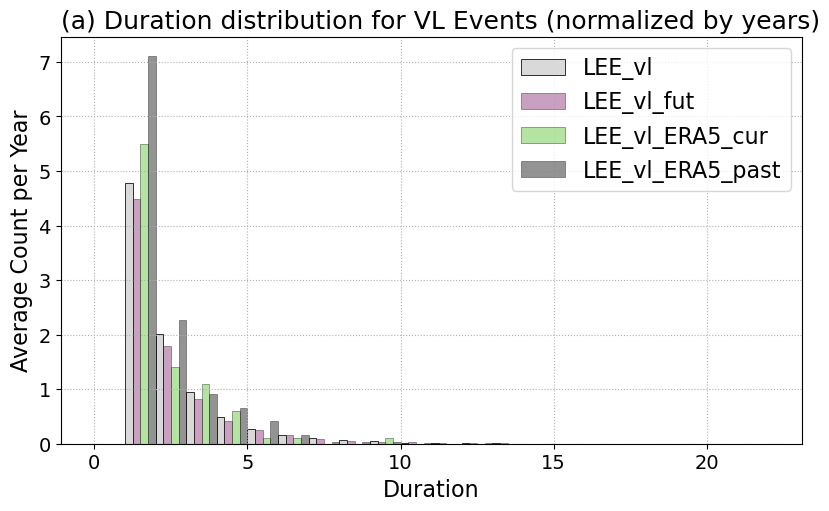

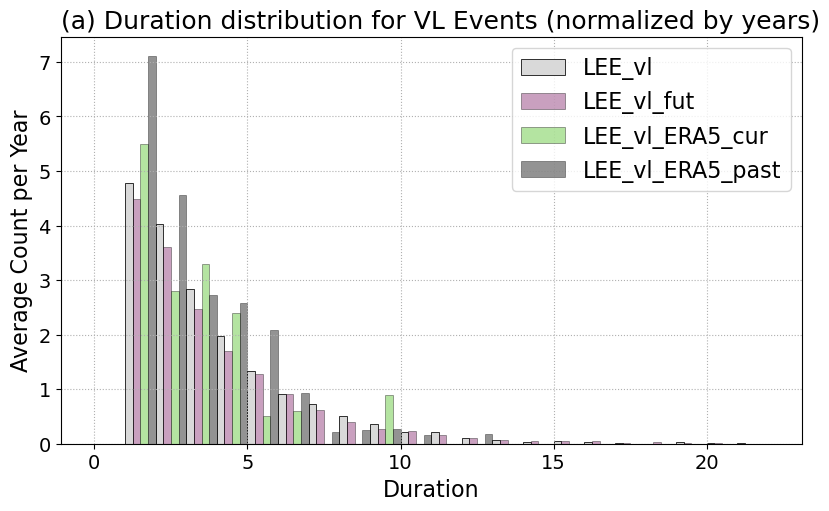

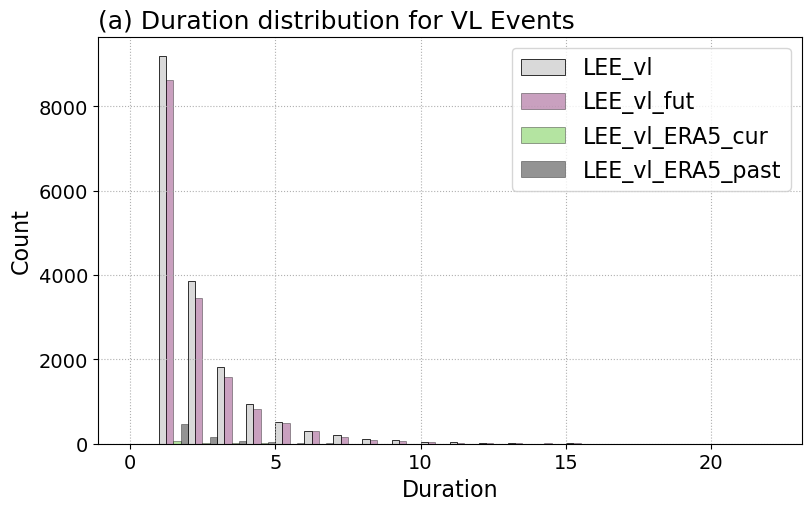

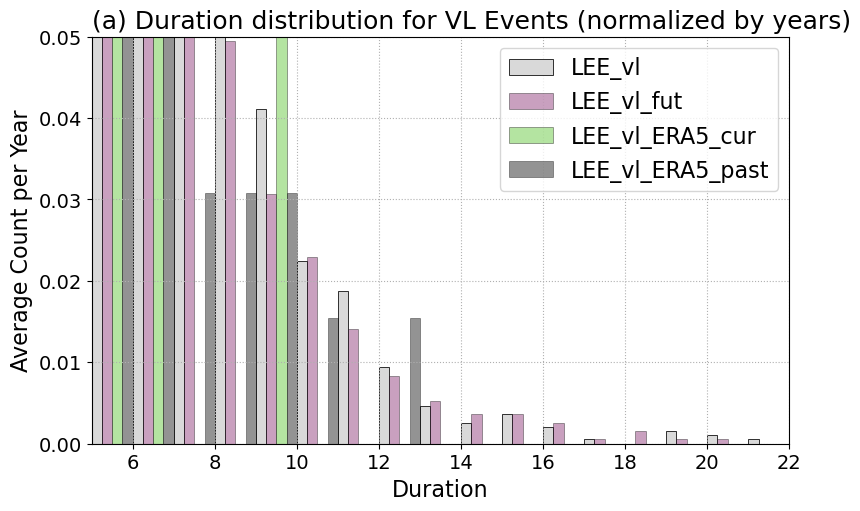

In [27]:


# Number of years for each dataset
years = [1920, 1920, 10, 65]
labels = ['LEE_vl', 'LEE_vl_fut', 'LEE_vl_ERA5_cur', 'LEE_vl_ERA5_past']
colors = [color_fill, '#882E72', "#5AC430", '#111111']
alphas = [fill_alpha, 0.45, 0.45, 0.45]

# Flatten the duration arrays
datasets = [dur, dur_fut, dur_ERA5_cur, dur_ERA5_past]

# Generate bin edges
bin_min, bin_max = 0, 22
bins = np.linspace(bin_min, bin_max, num=23)

# Plot
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# Calculate the width for each bar
n_datasets = len(datasets)
spacing = (bins[1] - bins[0]) / n_datasets   # spacing between bar centers
bar_width = spacing                   # 10% gap

# Plot each histogram side by side
for i, (data, year, label, color, alpha) in enumerate(zip(datasets, years, labels, colors, alphas)):
    # Calculate the offset for this dataset
    offset = (i - n_datasets/2 + 0.5) * spacing
    # Create shifted bins for this dataset
    shifted_bins = bins + offset
    
    counts, _ = np.histogram(data, bins=bins, weights=np.ones_like(data)/year)

    centers = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(
        centers + offset,
        counts,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=edge_color,
        linewidth=lw_edge,
        label=label,
    )

ax.set_xlabel('Duration')
ax.set_ylabel('Average Count per Year')
ax.set_title("(a) Duration distribution for VL Events (normalized by years)", loc='left')
ax.grid(True, linestyle=':', alpha=1)
ax.legend()

plt.show()

# Plot
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# Calculate the width for each bar
n_datasets = len(datasets)
spacing = (bins[1] - bins[0]) / n_datasets   # spacing between bar centers
bar_width = spacing                   # 10% gap

# Plot each histogram side by side
for i, (data, year, label, color, alpha) in enumerate(zip(datasets, years, labels, colors, alphas)):
    # Calculate the offset for this dataset
    offset = (i - n_datasets/2 + 0.5) * spacing
    # Create shifted bins for this dataset
    shifted_bins = bins + offset
    
    counts, _ = np.histogram(data, bins=bins, weights=np.ones_like(data)/year )

    # Multiply counts by the bin value
    counts = counts * bins[:-1]  # Multiply by the left edge of each bin

    centers = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(
        centers + offset,
        counts,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=edge_color,
        linewidth=lw_edge,
        label=label,
    )

ax.set_xlabel('Duration')
ax.set_ylabel('Average Count per Year')
ax.set_title("(a) Duration distribution for VL Events (normalized by years)", loc='left')
ax.grid(True, linestyle=':', alpha=1)
ax.legend()

plt.show()


# Plot
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# Calculate the width for each bar
n_datasets = len(datasets)
spacing = (bins[1] - bins[0]) / n_datasets   # spacing between bar centers
bar_width = spacing                   # 10% gap

# Plot each histogram side by side
for i, (data, year, label, color, alpha) in enumerate(zip(datasets, years, labels, colors, alphas)):
    # Calculate the offset for this dataset
    offset = (i - n_datasets/2 + 0.5) * spacing
    # Create shifted bins for this dataset
    shifted_bins = bins + offset
    
    counts, _ = np.histogram(data, bins=bins)#, weights=np.ones_like(data)/year)

    centers = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(
        centers + offset,
        counts,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=edge_color,
        linewidth=lw_edge,
        label=label,
    )

ax.set_xlabel('Duration')
ax.set_ylabel('Count')
ax.set_title("(a) Duration distribution for VL Events ", loc='left')
ax.grid(True, linestyle=':', alpha=1)
ax.legend()

plt.show()




# Plot
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

# Calculate the width for each bar
n_datasets = len(datasets)
spacing = (bins[1] - bins[0]) / n_datasets   # spacing between bar centers
bar_width = spacing                   # 10% gap

# Plot each histogram side by side
for i, (data, year, label, color, alpha) in enumerate(zip(datasets, years, labels, colors, alphas)):
    # Calculate the offset for this dataset
    offset = (i - n_datasets/2 + 0.5) * spacing
    # Create shifted bins for this dataset
    shifted_bins = bins + offset
    
    counts, _ = np.histogram(data, bins=bins, weights=np.ones_like(data)/year)

    centers = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(
        centers + offset,
        counts,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=edge_color,
        linewidth=lw_edge,
        label=label,
    )

ax.set_ylim(0, 0.05)
ax.set_xlim(5, bin_max)
ax.set_xlabel('Duration')
ax.set_ylabel('Average Count per Year')
ax.set_title("(a) Duration distribution for VL Events (normalized by years)", loc='left')
ax.grid(True, linestyle=':', alpha=1)
ax.legend()

plt.show()



In [28]:
LEE_vl.sort_values(by='duration', ascending=False)

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season,season_year
6763,2015-01-10,2015-01-30,2015-01-10 00:00:00.000000007,9,29,16,21,1464.164235,1405.166199,33.412016,29508.490189,6764,CESM2,CESM2_LE2-1281_007,2015,10,14/15,2014
5422,2017-01-18,2017-02-06,2017-01-18 00:00:00.000000003,747,766,750,20,1462.379438,1374.811083,35.027894,27496.221663,5423,CESM2,CESM2_LE2-1251_013,2017,18,16/17,2016
15418,2017-01-02,2017-01-21,2017-01-02 00:00:00.000000018,731,750,749,20,1457.396014,1401.686721,36.934278,28033.734427,15419,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r8i1p1f1,2017,2,16/17,2016
2295,2016-12-25,2017-01-12,2016-12-25 00:00:00.000000006,723,741,729,19,1518.537733,1447.241800,53.032482,27497.594203,2296,CESM2,CESM2_LE2-1191_010,2016,359,16/17,2016
9754,2015-12-24,2016-01-11,2015-12-24 00:00:00.000000001,357,375,358,19,1506.933629,1444.042109,34.777140,27436.800072,9755,CESM2,CESM2_LE2-1301_019,2015,358,15/16,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9266,2022-12-10,2022-12-10,2022-12-10 00:00:00.000000000,2898,2898,2898,1,1338.441262,1338.441262,0.000000,1338.441262,9267,CESM2,CESM2_LE2-1301_013,2022,344,22/23,2022
9264,2022-11-24,2022-11-24,2022-11-24 00:00:00.000000000,2882,2882,2882,1,1372.073568,1372.073568,0.000000,1372.073568,9265,CESM2,CESM2_LE2-1301_013,2022,328,22/23,2022
9263,2022-02-28,2022-02-28,2022-02-28 00:00:00.000000000,2613,2613,2613,1,1330.026721,1330.026721,0.000000,1330.026721,9264,CESM2,CESM2_LE2-1301_013,2022,59,21/22,2021
9262,2022-02-13,2022-02-13,2022-02-13 00:00:00.000000000,2598,2598,2598,1,1353.507906,1353.507906,0.000000,1353.507906,9263,CESM2,CESM2_LE2-1301_013,2022,44,21/22,2021


In [29]:
LEE_vl_fut.sort_values(by='duration', ascending=False)

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season,season_year
14879,2032-12-15,2033-01-03,2032-12-15 00:00:00.000000018,1078,1097,1096,20,1477.290971,1434.812177,34.369354,28696.243531,14880,UKESM1-0-LL,UKESM1-0-LL_r1i1p1f2,2041,349,32/33,2032
6880,2043-01-21,2043-02-08,2043-01-21 00:00:00.000000005,1480,1498,1485,19,1469.540934,1399.708974,38.558208,26594.470504,6881,CESM2,CESM2_LE2-1281_016,2043,21,42/43,2042
522,2045-12-13,2045-12-30,2045-12-13 00:00:00.000000004,2536,2553,2540,18,1467.095402,1394.714379,44.765555,25104.858827,523,CESM2,CESM2_LE2-1011_001,2045,347,45/46,2045
4823,2047-01-06,2047-01-23,2047-01-06 00:00:00.000000003,2925,2942,2928,18,1471.579088,1414.380369,40.023358,25458.846638,4824,CESM2,CESM2_LE2-1251_012,2047,6,46/47,2046
7898,2048-12-12,2048-12-29,2048-12-12 00:00:00.000000007,3630,3647,3637,18,1473.222962,1429.364961,38.166562,25728.569294,7899,CESM2,CESM2_LE2-1301_008,2048,346,48/49,2048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15685,2039-01-14,2039-01-14,2039-01-14 00:00:00.000000000,3298,3298,3298,1,1352.794293,1352.794293,0.000000,1352.794293,15686,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,14,38/39,2038
15684,2039-01-06,2039-01-06,2039-01-06 00:00:00.000000000,3290,3290,3290,1,1399.974070,1399.974070,0.000000,1399.974070,15685,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,6,38/39,2038
14,2035-03-21,2035-03-21,2035-03-21 00:00:00.000000000,444,444,444,1,1339.241420,1339.241420,0.000000,1339.241420,15,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2040,80,34/35,2034
13,2035-02-26,2035-02-26,2035-02-26 00:00:00.000000000,421,421,421,1,1336.215864,1336.215864,0.000000,1336.215864,14,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2040,57,34/35,2034


In [30]:
LEE_vl_ERA5_15_24.sort_values(by='duration', ascending=False)


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season,season_year
14283,2022-12-08,2022-12-16,2022-12-08 00:00:00.000000008,2896,2904,2904,9,1486.441387,1402.043198,38.249508,12618.388783,14284,ERA5_week,ERA5_hist_week,2022,342,22/23,2022
14211,2015-01-19,2015-01-24,2015-01-19 00:00:00.000000001,18,23,19,6,1439.293940,1385.690598,43.519127,8314.143589,14212,ERA5_week,ERA5_hist_week,2015,19,14/15,2014
14233,2017-01-21,2017-01-25,2017-01-21 00:00:00.000000002,750,754,752,5,1470.397466,1429.738376,28.746800,7148.691879,14234,ERA5_week,ERA5_hist_week,2017,21,16/17,2016
14220,2016-01-15,2016-01-18,2016-01-15 00:00:00.000000002,379,382,381,4,1412.025785,1370.237067,33.074269,5480.948269,14221,ERA5_week,ERA5_hist_week,2016,15,15/16,2015
14226,2016-12-03,2016-12-06,2016-12-03 00:00:00.000000003,701,704,704,4,1401.158381,1381.312283,15.967032,5525.249131,14227,ERA5_week,ERA5_hist_week,2016,337,16/17,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14286,2023-01-28,2023-01-28,2023-01-28 00:00:00.000000000,2947,2947,2947,1,1383.220249,1383.220249,0.000000,1383.220249,14287,ERA5_week,ERA5_hist_week,2023,28,22/23,2022
14294,2024-11-02,2024-11-02,2024-11-02 00:00:00.000000000,3590,3590,3590,1,1325.394895,1325.394895,0.000000,1325.394895,14295,ERA5_week,ERA5_hist_week,2024,306,24/25,2024
14293,2024-02-08,2024-02-08,2024-02-08 00:00:00.000000000,3323,3323,3323,1,1319.166494,1319.166494,0.000000,1319.166494,14294,ERA5_week,ERA5_hist_week,2024,39,23/24,2023
14297,2024-11-29,2024-11-29,2024-11-29 00:00:00.000000000,3617,3617,3617,1,1362.511620,1362.511620,0.000000,1362.511620,14298,ERA5_week,ERA5_hist_week,2024,333,24/25,2024


In [31]:
LEE_vl_ERA5_1960_.sort_values(by='duration', ascending=False)

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,winter_season,season_year
178,1973-01-01,1973-01-12,1973-01-01 00:00:00.000000003,4745,4756,4748,12,1462.266108,1396.537237,37.179937,16758.446850,179,ERA5_week,ERA5_hist_week,1973,-28/-27,1972
134,1969-12-04,1969-12-13,1969-12-04 00:00:00.000000002,3622,3631,3624,10,1503.532015,1419.140661,46.808938,14191.406609,135,ERA5_week,ERA5_hist_week,1969,-31/-30,1969
739,2022-12-08,2022-12-16,2022-12-08 00:00:00.000000008,22971,22979,22979,9,1486.441387,1402.043197,38.249508,12618.388775,740,ERA5_week,ERA5_hist_week,2022,22/23,2022
401,1992-12-24,1993-01-01,1992-12-24 00:00:00.000000002,12037,12045,12039,9,1461.847293,1391.221573,42.214545,12520.994159,402,ERA5_week,ERA5_hist_week,1992,-8/-7,1992
445,1996-12-06,1996-12-13,1996-12-06 00:00:00.000000005,13479,13486,13484,8,1456.644326,1389.753760,32.656570,11118.030079,446,ERA5_week,ERA5_hist_week,1996,-4/-3,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,1960-11-08,1960-11-08,1960-11-08 00:00:00.000000000,311,311,311,1,1373.949158,1373.949158,0.000000,1373.949158,9,ERA5_week,ERA5_hist_week,1960,-40/-39,1960
13,1960-12-29,1960-12-29,1960-12-29 00:00:00.000000000,362,362,362,1,1397.336147,1397.336147,0.000000,1397.336147,14,ERA5_week,ERA5_hist_week,1960,-40/-39,1960
14,1961-01-12,1961-01-12,1961-01-12 00:00:00.000000000,376,376,376,1,1329.113662,1329.113662,0.000000,1329.113662,15,ERA5_week,ERA5_hist_week,1961,-40/-39,1960
15,1961-02-05,1961-02-05,1961-02-05 00:00:00.000000000,400,400,400,1,1322.912394,1322.912394,0.000000,1322.912394,16,ERA5_week,ERA5_hist_week,1961,-40/-39,1960


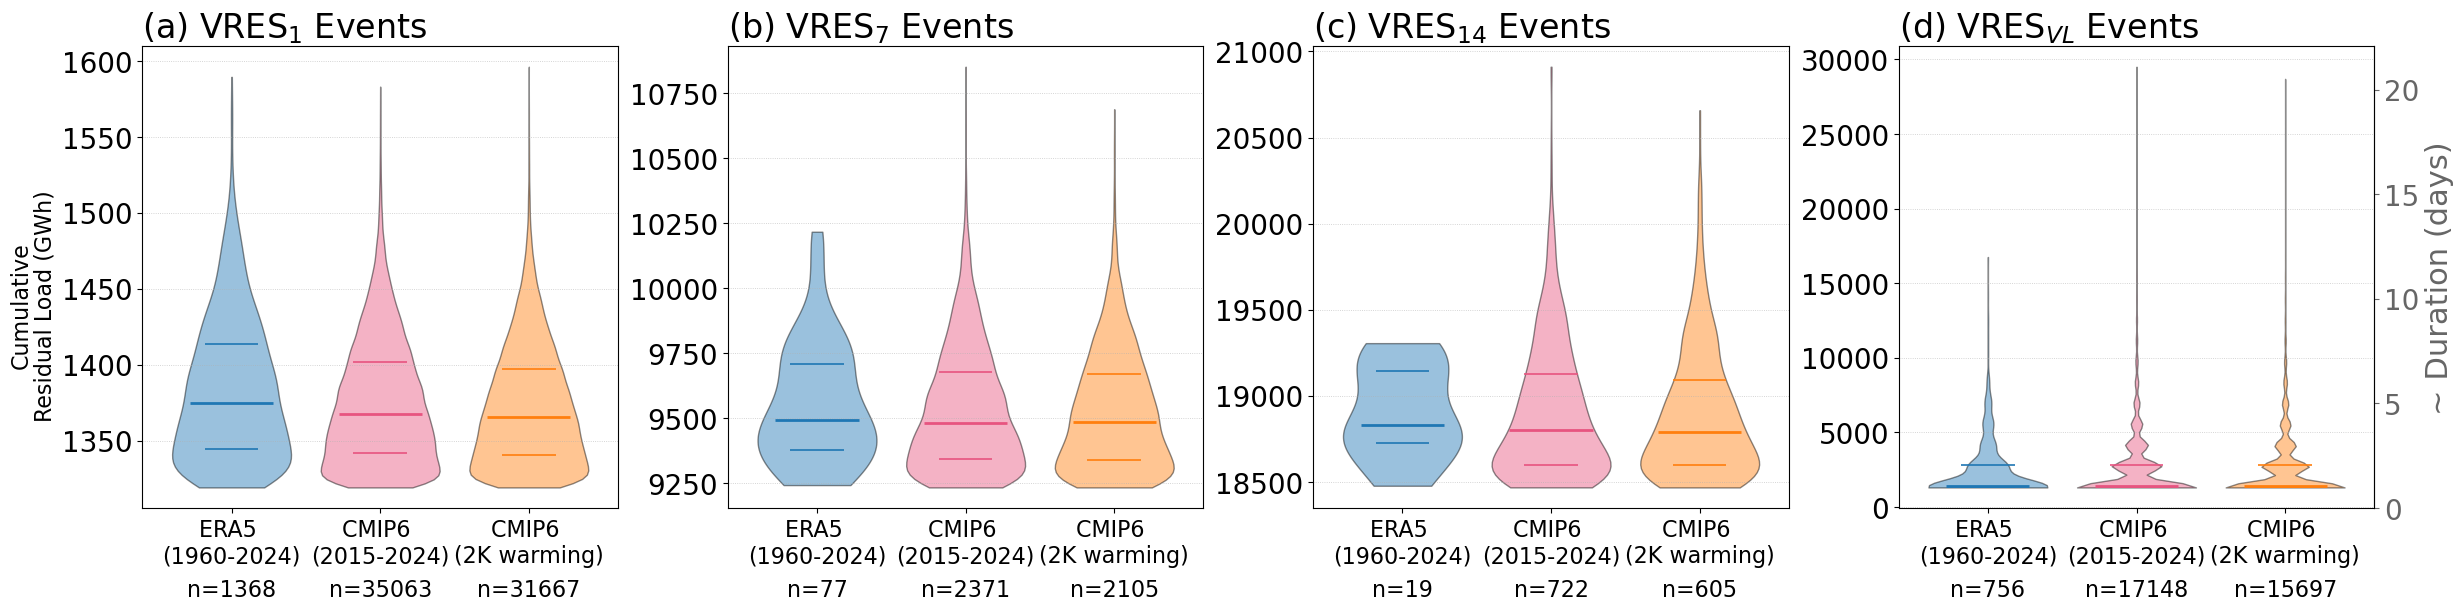

In [32]:
# keep text sizing consistent
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 16,
    'ytick.labelsize': 20,
    'legend.fontsize': 22,
    'figure.titlesize': 26,
})

def plot_violin_with_secondary(
    cmip_1_hist, cmip_1_fut, era_1,
    cmip_7_hist, cmip_7_fut, era_7,
    cmip_14_hist, cmip_14_fut, era_14,
    cmip_vl_hist, cmip_vl_fut, era_vl,
    cmip_vl_dur_hist, cmip_vl_dur_fut, era_vl_dur,
    outpath=None,
    colors=None,
    figsize=(24, 6),
    title_suffix="",
):
    """
    4-panel violin plot: 1d, 7d, 14d, VL
    Layout: ERA5 left, then CMIP historical, then CMIP future
    """
    if colors is None:
        colors = ['#1f77b4', '#e75480', '#ff7f0e']  # ERA5, CMIP hist, CMIP fut

    datasets = [
        (cmip_1_hist, cmip_1_fut, era_1, r"(a) $\mathrm{VRES}_{1}$ Events"),
        (cmip_7_hist, cmip_7_fut, era_7, r"(b) $\mathrm{VRES}_{7}$ Events"),
        (cmip_14_hist, cmip_14_fut, era_14, r"(c) $\mathrm{VRES}_{14}$ Events"),
        (cmip_vl_hist, cmip_vl_fut, era_vl, r"(d) $\mathrm{VRES}_{VL}$ Events"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    for ax, (cmip_hist, cmip_fut, era, title) in zip(axes, datasets):
        # assemble dataset and positions
        data_list = [era]
        positions = [1]

        if cmip_hist is not None:
            data_list.append(cmip_hist)
            positions.append(2)
        if cmip_fut is not None:
            data_list.append(cmip_fut)
            positions.append(3)

        # plot violin
        parts = ax.violinplot(dataset=data_list, positions=positions,
                              vert=True, widths=0.8, showextrema=False, showmedians=False)

        # style violins
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.45)

        # helper stats
        def safe_stats(arr):
            arr = np.asarray(arr)
            arr = arr[~np.isnan(arr)]
            return {
                'median': np.median(arr) if arr.size else np.nan,
                'q1': np.percentile(arr, 25) if arr.size else np.nan,
                'q3': np.percentile(arr, 75) if arr.size else np.nan,
                'min': np.min(arr) if arr.size else np.nan,
                'max': np.max(arr) if arr.size else np.nan,
                'n': arr.size,
            }

        stats_list = [safe_stats(d) for d in data_list]

        for i, pos in enumerate(positions):
            stats = stats_list[i]
            color = colors[i]
            if not np.isnan(stats['median']):
                ax.hlines(stats['median'], pos - 0.28, pos + 0.28, color=color, linewidth=2)
            if not np.isnan(stats['q1']) and not np.isnan(stats['q3']):
                ax.hlines(stats['q1'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
                ax.hlines(stats['q3'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
            if not np.isnan(stats['min']):
                ax.vlines(pos - 0.08, stats['min'], stats['min'], color=color, linewidth=2)
            if not np.isnan(stats['max']):
                ax.vlines(pos + 0.08, stats['max'], stats['max'], color=color, linewidth=2)
            ax.text(pos, -0.2, f"n={stats['n']}", transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', color='black')

        ax.set_xticks(positions)
        ax.set_xticklabels(['ERA5 \n(1960-2024)', 'CMIP6 \n(2015-2024)', 'CMIP6 \n(2K warming)'])
        ax.set_xlim(0.4, 3.6)
        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

    
    # --- Add secondary axes for mean daily RL to panels 2 and 3 ---
    # for ax, divisor, label in zip(axes[1:3], [7, 14], ['7-day mean', '14-day mean']):
    #     secax = ax.secondary_yaxis('right', functions=(lambda y, d=divisor: y/d,
    #                                                 lambda y, d=divisor: y*d))
    #     secax.set_ylabel(f'Mean Daily RL ({label})')
    #     secax.spines['right'].set_color('#666666')
    #     secax.yaxis.label.set_color('#666666')
    #     secax.tick_params(axis='y', colors='#666666')
    #     secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    
    # Secondary y-axis for VL
    ax_vl = axes[-1]

    X = np.concatenate([np.asarray(cmip_vl_hist).ravel(),
                        np.asarray(cmip_vl_fut).ravel(),
                        np.asarray(era_vl).ravel()])
    Y = np.concatenate([np.asarray(cmip_vl_dur_hist).ravel(),
                        np.asarray(cmip_vl_dur_fut).ravel(),
                        np.asarray(era_vl_dur).ravel()])
    mask = np.isfinite(X) & np.isfinite(Y)
    Xf, Yf = X[mask], Y[mask]

    slope, intercept = np.polyfit(Xf, Yf, 1)
    if abs(slope) < 1e-12:
        forward = lambda y: y
        inverse = lambda d: d
    else:
        forward = lambda y, a=slope, b=intercept: a*y + b
        inverse = lambda d, a=slope, b=intercept: (d - b)/a

    secax = ax_vl.secondary_yaxis('right', functions=(forward, inverse))
    secax.spines['right'].set_color('#666666')
    secax.yaxis.label.set_color('#666666')
    secax.tick_params(axis='y', colors='#666666')
    secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    secax.set_ylabel('~ Duration (days)')

    fig.text(-0.02, 0.5, 'Cumulative', va='center', rotation='vertical')
    fig.text(-0.01, 0.5, 'Residual Load (GWh)', va='center', rotation='vertical')

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes
# Example usage (your variables should be defined in the namespace):
fig, axes = plot_violin_with_secondary(
    cmip_1_hist = LEE_dat_CMIP['RL_cumulative'],
    cmip_1_fut  = LEE_dat_fut['RL_cumulative'],  # or LEE_dat_CMIP
    era_1   = LEE_dat_ERA5['RL_cumulative'],
    cmip_7_hist = LEE_7_CMIP['RL_cumulative'],
    cmip_7_fut  = LEE_7_fut['RL_cumulative'],
    era_7   = LEE_7_ERA5['RL_cumulative'],
    cmip_14_hist = LEE_14_CMIP['RL_cumulative'],
    cmip_14_fut  = LEE_14_fut['RL_cumulative'],
    era_14  = LEE_14_ERA5['RL_cumulative'],
    cmip_vl_hist = LEE_vl_CMIP['RL_cumulative'],
    cmip_vl_fut  = LEE_vl_fut['RL_cumulative'],
    era_vl  = LEE_vl_ERA5['RL_cumulative'],
    cmip_vl_dur_hist = LEE_vl_CMIP['duration'],
    cmip_vl_dur_fut = LEE_vl_fut['duration'],
    era_vl_dur  = LEE_vl_ERA5['duration'],
    # outpath='/home/onennecke/Code/Figures/VRES_RL_cumulative_violin_comparison.png',
)



Primary min: 1319.14, Primary max: 1596.22


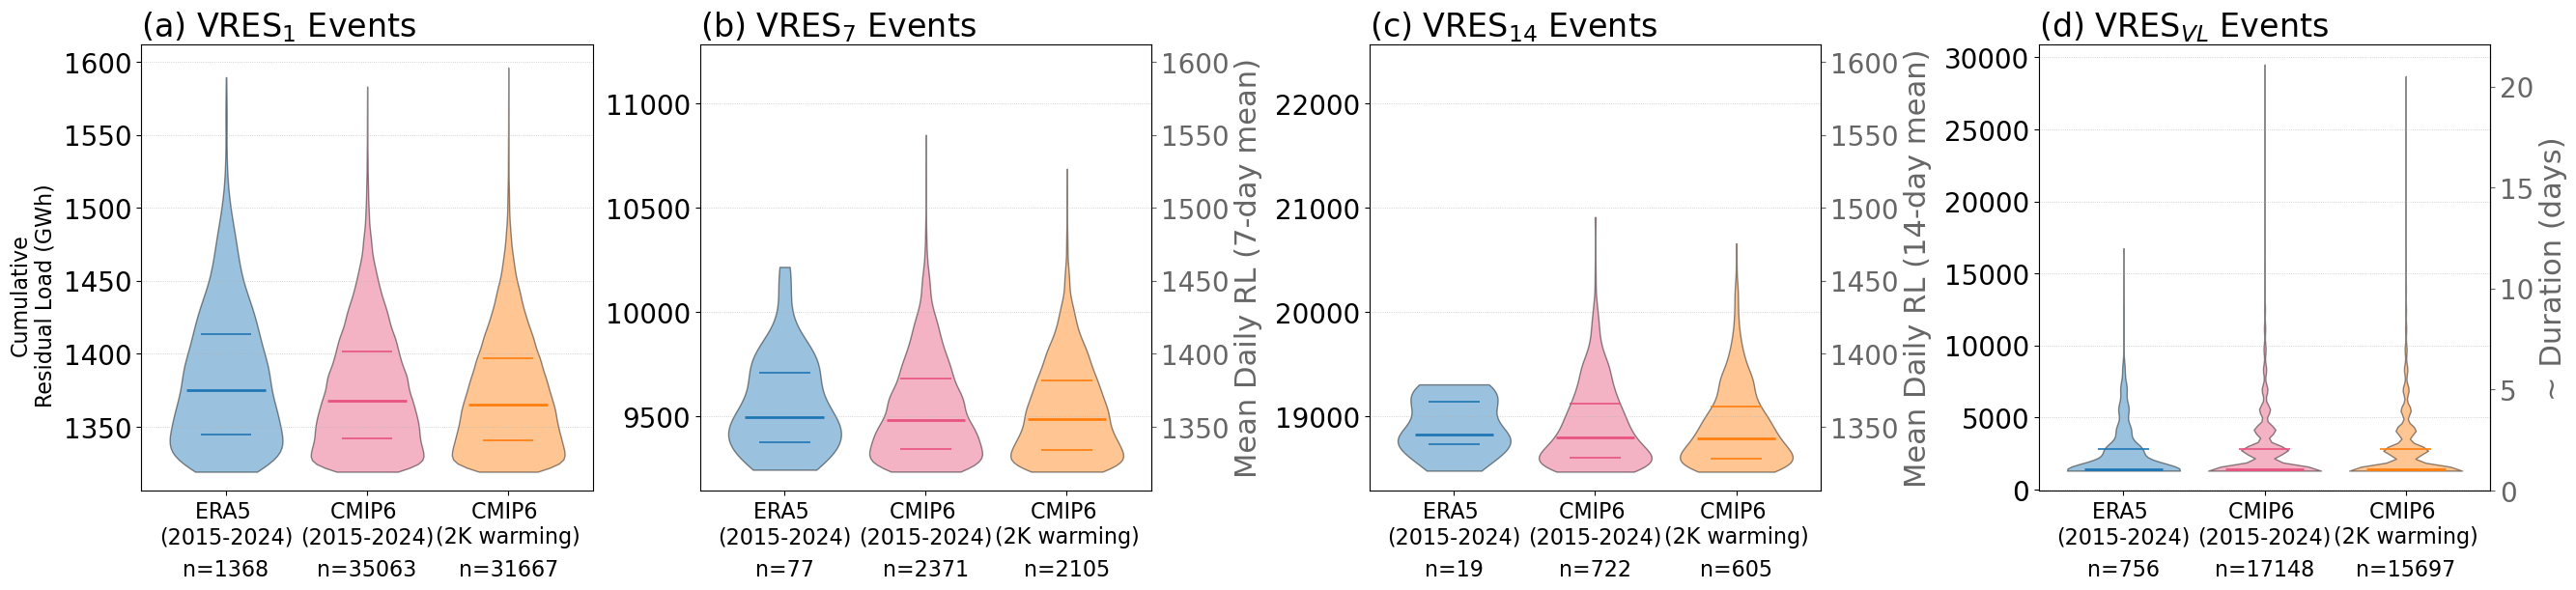

In [33]:
# keep text sizing consistent
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 16,
    'ytick.labelsize': 20,
    'legend.fontsize': 22,
    'figure.titlesize': 26,
})

def plot_violin_with_secondary(
    cmip_1_hist, cmip_1_fut, era_1,
    cmip_7_hist, cmip_7_fut, era_7,
    cmip_14_hist, cmip_14_fut, era_14,
    cmip_vl_hist, cmip_vl_fut, era_vl,
    cmip_vl_dur_hist, cmip_vl_dur_fut, era_vl_dur,
    outpath=None,
    colors=None,
    figsize=(26, 6),
    title_suffix="",
):
    """
    4-panel violin plot: 1d, 7d, 14d, VL
    Layout: ERA5 left, then CMIP historical, then CMIP future
    """
    if colors is None:
        colors = ['#1f77b4', '#e75480', '#ff7f0e']  # ERA5, CMIP hist, CMIP fut

    datasets = [
        (cmip_1_hist, cmip_1_fut, era_1, r"(a) $\mathrm{VRES}_{1}$ Events"),
        (cmip_7_hist, cmip_7_fut, era_7, r"(b) $\mathrm{VRES}_{7}$ Events"),
        (cmip_14_hist, cmip_14_fut, era_14, r"(c) $\mathrm{VRES}_{14}$ Events"),
        (cmip_vl_hist, cmip_vl_fut, era_vl, r"(d) $\mathrm{VRES}_{VL}$ Events"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    for ax, (cmip_hist, cmip_fut, era, title) in zip(axes, datasets):
        # assemble dataset and positions
        data_list = [era]
        positions = [1]

        if cmip_hist is not None:
            data_list.append(cmip_hist)
            positions.append(2)
        if cmip_fut is not None:
            data_list.append(cmip_fut)
            positions.append(3)

        # plot violin
        parts = ax.violinplot(dataset=data_list, positions=positions,
                              vert=True, widths=0.8, showextrema=False, showmedians=False)

        # style violins
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.45)

        # helper stats
        def safe_stats(arr):
            arr = np.asarray(arr)
            arr = arr[~np.isnan(arr)]
            return {
                'median': np.median(arr) if arr.size else np.nan,
                'q1': np.percentile(arr, 25) if arr.size else np.nan,
                'q3': np.percentile(arr, 75) if arr.size else np.nan,
                'min': np.min(arr) if arr.size else np.nan,
                'max': np.max(arr) if arr.size else np.nan,
                'n': arr.size,
            }

        stats_list = [safe_stats(d) for d in data_list]

        for i, pos in enumerate(positions):
            stats = stats_list[i]
            color = colors[i]
            if not np.isnan(stats['median']):
                ax.hlines(stats['median'], pos - 0.28, pos + 0.28, color=color, linewidth=2)
            if not np.isnan(stats['q1']) and not np.isnan(stats['q3']):
                ax.hlines(stats['q1'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
                ax.hlines(stats['q3'], pos - 0.18, pos + 0.18, color=color, linewidth=1.2)
            if not np.isnan(stats['min']):
                ax.vlines(pos - 0.08, stats['min'], stats['min'], color=color, linewidth=2)
            if not np.isnan(stats['max']):
                ax.vlines(pos + 0.08, stats['max'], stats['max'], color=color, linewidth=2)
            ax.text(pos, -0.2, f"n={stats['n']}", transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', color='black')

        ax.set_xticks(positions)
        ax.set_xticklabels(['ERA5 \n(2015-2024)', 'CMIP6 \n(2015-2024)', 'CMIP6 \n(2K warming)'])
        ax.set_xlim(0.4, 3.6)
        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

        ax.set_title(f"{title} {title_suffix}".strip(), loc='left')
        ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

    
    # --- Add secondary axes for mean daily RL to panels 2 and 3 ---
    for ax, divisor, label in zip(axes[1:3], [7, 14], ['7-day mean', '14-day mean']):
        secax = ax.secondary_yaxis('right', functions=(lambda y, d=divisor: y/d,
                                                    lambda y, d=divisor: y*d))
        secax.set_ylabel(f'Mean Daily RL ({label})')
        secax.spines['right'].set_color('#666666')
        secax.yaxis.label.set_color('#666666')
        secax.tick_params(axis='y', colors='#666666')
        secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    
    # --- Determine common y-limits for panels 1-3 ---
    # Get primary min for first panel
    y1_min = np.nanmin(np.concatenate([np.asarray(cmip_1_hist),
                                    np.asarray(cmip_1_fut),
                                    np.asarray(era_1)]))

    # Get secondary min for panels 2 and 3
    y2_min = np.nanmin(np.concatenate([
                np.asarray(cmip_7_hist)/7 if cmip_7_hist is not None else [],
                np.asarray(cmip_7_fut)/7 if cmip_7_fut is not None else [],
                np.asarray(era_7)/7,
                np.asarray(cmip_14_hist)/14 if cmip_14_hist is not None else [],
                np.asarray(cmip_14_fut)/14 if cmip_14_fut is not None else [],
                np.asarray(era_14)/14
            ]))
    # Get primary max for first panel
    y1_max = max(np.nanmax(np.concatenate([np.asarray(cmip_1_hist), np.asarray(cmip_1_fut), np.asarray(era_1)])), 0)

    # Get secondary max for panels 2 and 3
    y2_max = max(np.nanmax(np.concatenate([np.asarray(cmip_7_hist)/7 if cmip_7_hist is not None else [],
                                        np.asarray(cmip_7_fut)/7 if cmip_7_fut is not None else [],
                                        np.asarray(era_7)/7])),
                np.nanmax(np.concatenate([np.asarray(cmip_14_hist)/14 if cmip_14_hist is not None else [],
                                        np.asarray(cmip_14_fut)/14 if cmip_14_fut is not None else [],
                                        np.asarray(era_14)/14])))
    print(f"Primary min: {y1_min:.2f}, Primary max: {y1_max:.2f}")
    common_ylim = (min(y1_min, y2_min)*0.99, max(y1_max, y2_max)*1.01)  # slight padding

    # Apply to first three axes
    axes[0].set_ylim(common_ylim)  # primary y for panel 1
    axes[1].set_ylim(common_ylim[0]*7, common_ylim[1]*7)  # scale back to primary y
    axes[2].set_ylim(common_ylim[0]*14, common_ylim[1]*14)
    
    # Secondary y-axis for VL
    ax_vl = axes[-1]

    X = np.concatenate([np.asarray(cmip_vl_hist).ravel(),
                        np.asarray(cmip_vl_fut).ravel(),
                        np.asarray(era_vl).ravel()])
    Y = np.concatenate([np.asarray(cmip_vl_dur_hist).ravel(),
                        np.asarray(cmip_vl_dur_fut).ravel(),
                        np.asarray(era_vl_dur).ravel()])
    mask = np.isfinite(X) & np.isfinite(Y)
    Xf, Yf = X[mask], Y[mask]

    slope, intercept = np.polyfit(Xf, Yf, 1)
    if abs(slope) < 1e-12:
        forward = lambda y: y
        inverse = lambda d: d
    else:
        forward = lambda y, a=slope, b=intercept: a*y + b
        inverse = lambda d, a=slope, b=intercept: (d - b)/a

    secax = ax_vl.secondary_yaxis('right', functions=(forward, inverse))
    secax.spines['right'].set_color('#666666')
    secax.yaxis.label.set_color('#666666')
    secax.tick_params(axis='y', colors='#666666')
    secax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5)
    secax.set_ylabel('~ Duration (days)')

    fig.text(-0.02, 0.5, 'Cumulative', va='center', rotation='vertical')
    fig.text(-0.01, 0.5, 'Residual Load (GWh)', va='center', rotation='vertical')

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes
# Example usage (your variables should be defined in the namespace):
fig, axes = plot_violin_with_secondary(
    cmip_1_hist = LEE_dat_CMIP['RL_cumulative'],
    cmip_1_fut  = LEE_dat_fut['RL_cumulative'],  # or LEE_dat_CMIP
    era_1   = LEE_dat_ERA5['RL_cumulative'],
    cmip_7_hist = LEE_7_CMIP['RL_cumulative'],
    cmip_7_fut  = LEE_7_fut['RL_cumulative'],
    era_7   = LEE_7_ERA5['RL_cumulative'],
    cmip_14_hist = LEE_14_CMIP['RL_cumulative'],
    cmip_14_fut  = LEE_14_fut['RL_cumulative'],
    era_14  = LEE_14_ERA5['RL_cumulative'],
    cmip_vl_hist = LEE_vl_CMIP['RL_cumulative'],
    cmip_vl_fut  = LEE_vl_fut['RL_cumulative'],
    era_vl  = LEE_vl_ERA5['RL_cumulative'],
    cmip_vl_dur_hist = LEE_vl_CMIP['duration'],
    cmip_vl_dur_fut = LEE_vl_fut['duration'],
    era_vl_dur  = LEE_vl_ERA5['duration'],
    # outpath='/home/onennecke/Code/Figures/VRES_RL_cumulative_violin_comparison.png',
)



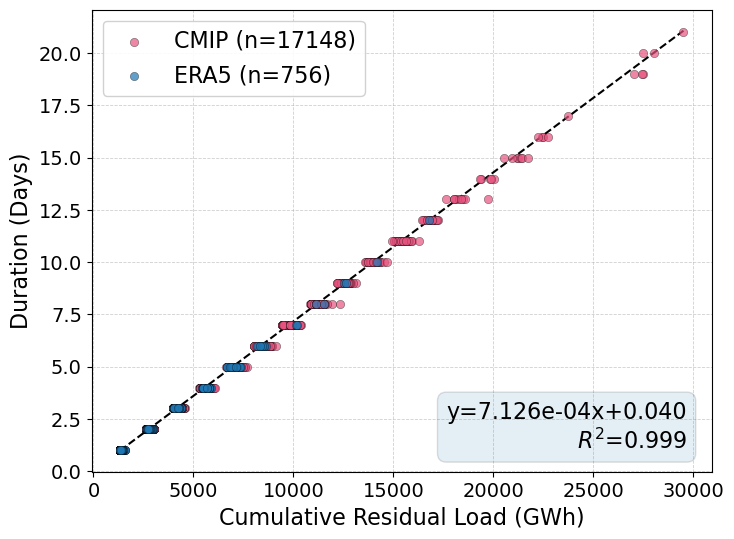

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Cumulative Residual Load (GWh)', ylabel='Duration (Days)'>)

In [34]:
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# If you have scipy you can compute a more formal r-value; otherwise we compute R^2 manually
try:
    from scipy.stats import linregress
    _have_scipy = True
except Exception:
    _have_scipy = False

def scatter_rl_vs_duration(
    cmip_rl, cmip_dur,
    era_rl, era_dur,
    figsize=(8,6),
    colors=['#e75480', '#1f77b4'],
    title="VL events: cumulative RL vs duration",
    outpath=None
):
    # flatten and clean
    cmip_rl = np.asarray(cmip_rl).ravel()
    cmip_dur = np.asarray(cmip_dur).ravel()
    era_rl  = np.asarray(era_rl).ravel()
    era_dur = np.asarray(era_dur).ravel()

    mask_cmip = np.isfinite(cmip_rl) & np.isfinite(cmip_dur)
    mask_era  = np.isfinite(era_rl)  & np.isfinite(era_dur)

    x_cmip = cmip_rl[mask_cmip]
    y_cmip = cmip_dur[mask_cmip]
    x_era  = era_rl[mask_era]
    y_era  = era_dur[mask_era]

    # combined
    x_all = np.concatenate([x_cmip, x_era])
    y_all = np.concatenate([y_cmip, y_era])

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(x_cmip, y_cmip, label=f'CMIP (n={x_cmip.size})', c=colors[0], alpha=0.7, edgecolor='k', linewidth=0.3, zorder=3)
    ax.scatter(x_era, y_era, label=f'ERA5 (n={x_era.size})', c=colors[1], alpha=0.7, edgecolor='k', linewidth=0.3, zorder=3)

    # Fit lines: combined and per-dataset
    def fit_and_plot(x, y, label, color, linestyle='-'):
        if x.size < 2:
            return None
        if _have_scipy:
            lr = linregress(x, y)
            slope, intercept, r2 = lr.slope, lr.intercept, lr.rvalue**2
        else:
            slope, intercept = np.polyfit(x, y, 1)
            ypred = slope * x + intercept
            ss_res = np.sum((y - ypred)**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

        xs = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 200)
        ax.plot(xs, slope * xs + intercept, linestyle=linestyle, color=color, linewidth=1.5, zorder=2)#,
                # label=f"{label} fit: y={slope:.3e}x+{intercept:.3f}, $R^2$={r2:.3f}", linewidth=1.5, zorder=2)
        return slope, intercept, r2

    fit_all = fit_and_plot(x_all, y_all, 'Combined', '#000000', linestyle='--')
    # fit_cmip = fit_and_plot(x_cmip, y_cmip, 'CMIP', colors[0], linestyle='--')
    # fit_era  = fit_and_plot(x_era, y_era, 'ERA5', colors[1], linestyle=':')

    ax.set_xlabel('Cumulative Residual Load (GWh)')
    ax.set_ylabel('Duration (Days)')
    # ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    ax.legend(loc='best', framealpha=0.9)

    # small textbox with combined-fit stats to make it explicit
    if fit_all is not None:
        s, i, r2 = fit_all
        ax.text(0.96, 0.04, f"y={s:.3e}x+{i:.3f}\n$R^2$={r2:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                bbox=dict(boxstyle="round,pad=0.4", alpha=0.12))

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Example call (replace with your arrays):
scatter_rl_vs_duration(
    cmip_rl = LEE_vl_CMIP['RL_cumulative'],
    cmip_dur = LEE_vl_CMIP['duration'],
    era_rl  = LEE_vl_ERA5['RL_cumulative'],
    era_dur = LEE_vl_ERA5['duration'],
    # outpath='/home/onennecke/Code/Figures/LEE_vl_RL_vs_duration_fit.png'
)


# Return time plots

In [35]:
# Function to add a winter season coordinate to an xarray Dataset
def add_winter_season_coordinate(ds, time_dim='time'):
    # Ensure the time coordinate is in datetime format
    time_values = pd.to_datetime(ds[time_dim].values)
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    # def get_winter_season(date):
    #     year = date.year
    #     if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
    #         return year
    #     else:  # January, February, March, April, May, June belong to the current year's winter
    #         return year-1
    # Apply the function to create a new array of winter seasons
    winter_seasons = np.array([get_winter_season(date) for date in time_values])

    # Add the new coordinate to the Dataset
    ds = ds.assign_coords(winter_season=(time_dim, winter_seasons))
    return ds

In [36]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'
files = [path]

ds = xr.open_dataset(path)

ds = add_winter_season_coordinate(ds, time_dim='time')

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()


ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

res_load_fut = ts_datasets['Residual_load']
# Unravel the arrays to 1D for easier handling
res_load_fut_1d = res_load_fut.values.ravel()

res_load_fut_7d = res_load_fut.rolling(time=7, center=False).mean()
res_load_fut_14d = res_load_fut.rolling(time=14, center=False).mean()


In [37]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)
ds = add_winter_season_coordinate(ds, time_dim='time')

ts_datasets_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ts_datasets_ERA5.load()
res_load_era5_15_24 = ts_datasets_ERA5['Residual_load']
res_load_era5_15_24_1d = res_load_era5_15_24.values.ravel()

res_load_era5_15_24_7d = res_load_era5_15_24.rolling(time=7, center=False).mean()
res_load_era5_15_24_14d = res_load_era5_15_24.rolling(time=14, center=False).mean()

ts_datasets_curr_clim = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist') & (ds.ESM_run != 'ERA5_hist_week'),drop=True)
ts_datasets_curr_clim.load()

res_load_curr_clim = ts_datasets_curr_clim['Residual_load']
# Unravel the arrays to 1D for easier handling
res_load_curr_clim_1d = res_load_curr_clim.values.ravel()

res_load_curr_clim_7d = res_load_curr_clim.rolling(time=7, center=False).mean()
res_load_curr_clim_14d = res_load_curr_clim.rolling(time=14, center=False).mean()


In [38]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_all_years/ERA5_hist_timeseries.nc'

ts_datasets_ERA5 = xr.open_dataset(path)
ts_datasets_ERA5 = add_winter_season_coordinate(ts_datasets_ERA5, time_dim='time')
ts_datasets_ERA5.load()
res_load_ERA5 = ts_datasets_ERA5['Residual_load']

res_load_ERA5_7d = res_load_ERA5.rolling(time=7, center=False).mean()
res_load_ERA5_14d = res_load_ERA5.rolling(time=14, center=False).mean()

In [39]:
res_load_ERA5_1960_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year < 1990), drop=True)['Residual_load']
res_load_ERA5_1990_2014 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year <= 2014), drop=True)['Residual_load']

res_load_ERA5_1960_1970 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year < 1970), drop=True)['Residual_load']
res_load_ERA5_1970_1980 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1970) & (ts_datasets_ERA5.time.dt.year < 1980), drop=True)['Residual_load']
res_load_ERA5_1980_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1980) & (ts_datasets_ERA5.time.dt.year < 1990), drop=True)['Residual_load']
res_load_ERA5_1990_2000 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year < 2000), drop=True)['Residual_load']
res_load_ERA5_2000_2010 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2000) & (ts_datasets_ERA5.time.dt.year < 2010), drop=True)['Residual_load']
res_load_ERA5_2010_2020 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2010) & (ts_datasets_ERA5.time.dt.year < 2020), drop=True)['Residual_load']
res_load_ERA5_2020_2024 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2020) & (ts_datasets_ERA5.time.dt.year <= 2024), drop=True)['Residual_load']

res_load_ERA5_2015_2019 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2015) & (ts_datasets_ERA5.time.dt.year < 2020), drop=True)['Residual_load']

In [40]:
RLs = [res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]

means = [np.mean(rl.values) for rl in RLs]
means



[np.float64(860.1621306403575),
 np.float64(859.4199188776411),
 np.float64(839.95045701852),
 np.float64(815.5844556709305),
 np.float64(834.3953956698805),
 np.float64(841.3180129912308),
 np.float64(825.7675504187749)]

In [41]:
res_load_ERA5_2015_2024 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2015) & (ts_datasets_ERA5.time.dt.year <= 2024), drop=True)['Residual_load']
res_load_ERA5_2015_2024

<xarray.DataArray 'Residual_load' (time: 3650)> Size: 29kB
array([ 533.62954852, -124.66275289,  290.84286213, ...,  984.9126268 ,
        457.11872085,  402.62437437])
Coordinates:
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U9 36B 'ERA5_week'
    run            <U4 16B 'hist'
    ESM_run        <U14 56B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    winter_season  (time) <U7 102kB '14/15' '14/15' '14/15' ... '24/25' '24/25'

In [42]:
max(max(res_load_ERA5), max(res_load_curr_clim_1d), max(res_load_fut_1d))
# == np.float64(1596.223514139268)


np.float64(1596.223514139268)

In [43]:
# Connect both ERA5 periods to the same plot to see if they differ in the recent years (2015-2024)
res_load_tst = xr.concat([res_load_ERA5_2015_2019, res_load_ERA5_2020_2024], dim='time').values

# Check if they are exactly the same (they should be)
# np.allclose(res_load_tst, res_load_ERA5_2015_2024.values)


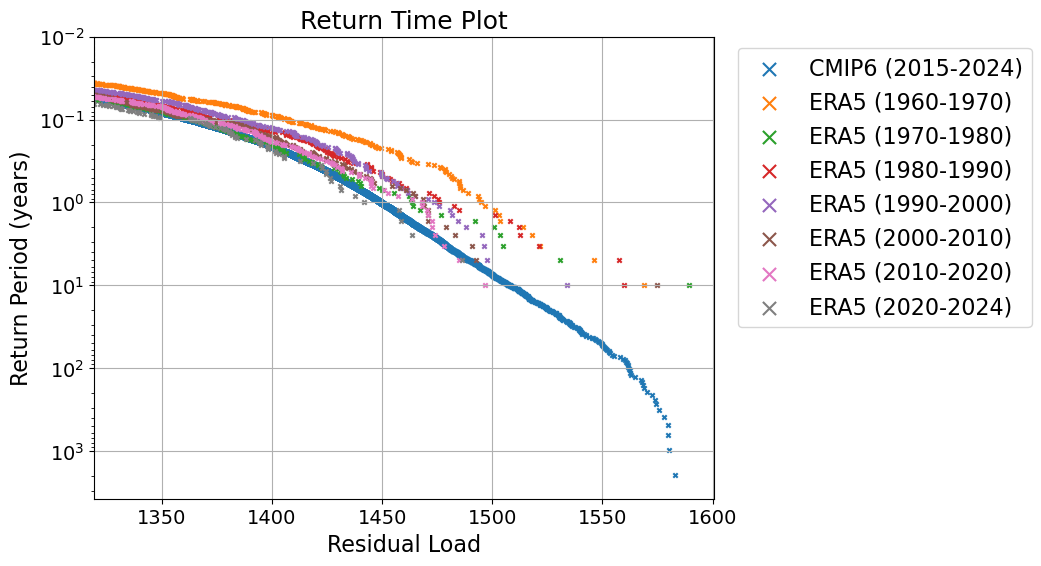

In [44]:
# This is only for the 1d values (but correct otherwise)

RLs = [# res_load_ERA5, 
       res_load_curr_clim_1d,# res_load_era5_15_24_1d,
       res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
labels = [#'ERA5 (1960-2024)', 
          'CMIP6 (2015-2024)',# 'ERA5 (2015-2024)',
          'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
          'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# Non inverted Plot
'''plt.figure(figsize=(8,6))

for res_load, label in zip(RLs, labels):
    extremes = res_load # your event values
    # Sort ascending
    x = np.sort(extremes)
    # Rank
    m = np.arange(1, len(x) + 1)
    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method
    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = 1 / (1 - (m/(N+1))) / 365 # equivalent, more direct formula
    
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
plt.xlim(np.float64(1319.138650687668), max(np.nanmax(rl) for rl in RLs)*1.007)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)
# plt.gca().invert_yaxis()  # rare events (small prob) at the bottom

plt.ylim(10**-2, None)
# plt.ylabel('exceedance probability')
plt.ylabel('Return Period (years)')

plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, markerscale=3)
plt.grid(True)
plt.show()'''


# Inverted Plot
plt.figure(figsize=(8,6))

for res_load, label in zip(RLs, labels):
    extremes = res_load # your event values
    # Sort ascending
    x = np.sort(extremes)
    # Rank
    m = np.arange(1, len(x) + 1)
    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method
    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = 1 / (1 - (m/(N+1))) / 365 # equivalent, more direct formula
    
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
plt.xlim(np.float64(1319.138650687668), max(np.nanmax(rl) for rl in RLs)*1.007)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)
plt.gca().invert_yaxis()  # rare events (small prob) at the bottom

plt.ylim(None, 10**-2)
# plt.ylabel('exceedance probability')
plt.ylabel('Return Period (years)')

plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, markerscale=3)

plt.grid(True)
plt.show()


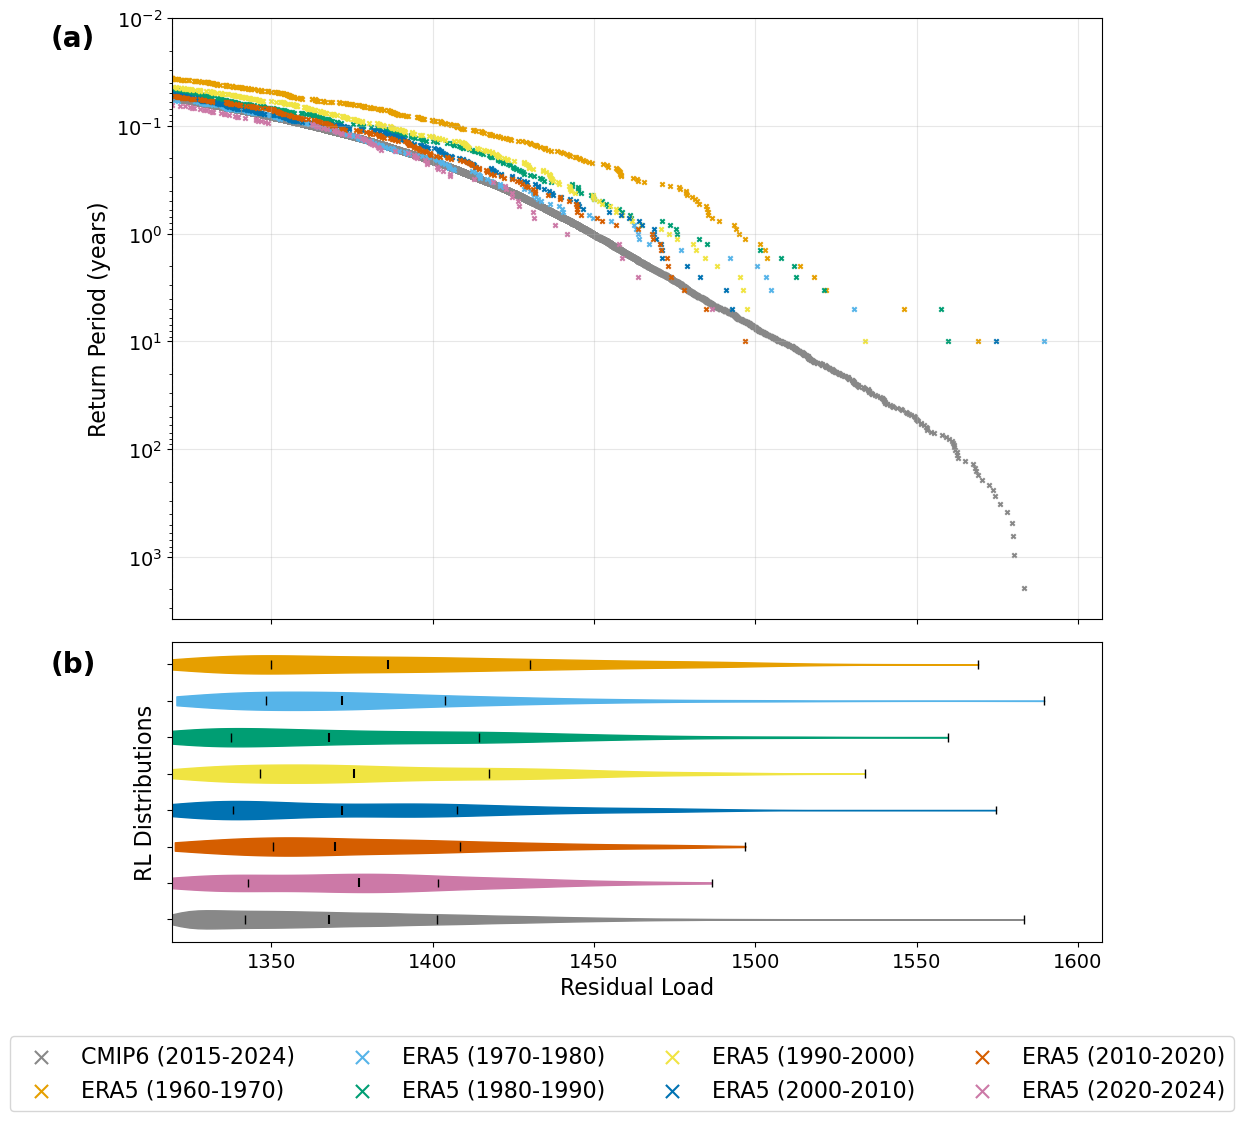

In [45]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})


RLs = [# res_load_ERA5, 
       res_load_curr_clim_1d,# res_load_era5_15_24_1d,
       res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
labels = [#'ERA5 (1960-2024)', 
          'CMIP6 (2015-2024)',# 'ERA5 (2015-2024)',
          'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
          'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']
# RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]
# labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-2024)', 'ERA5 (2015-2024)']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]


# Create figure with two vertically stacked axes
fig = plt.figure(figsize=(12, 12))
gs = GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.05)

ax_rt = fig.add_subplot(gs[0])
ax_violin = fig.add_subplot(gs[1], sharex=ax_rt)
colors = []
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(RLs)]
# Okabe-Ito colour-blind friendly palette
colors = [
    "#888888",  # grey
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]
# -------------------------
# Return time plot
# -------------------------
for i, (res_load, label) in enumerate(zip(RLs, labels)):

    extremes = np.asarray(res_load)

    x = np.sort(extremes)
    m = np.arange(1, len(x) + 1)
    N = len(extremes)

    T = (1 / (1 - (m / (N + 1)))) / 365 

    sc = ax_rt.scatter(
        x,
        T,
        marker='x',
        color=colors[i],
        s=10,
        label=label
    )
    colors.append(sc.get_facecolor()[0])
threshold = np.float64(1319.138650687668)

ax_rt.axvline(
    threshold,
    color='gray',
    linestyle='--',
    linewidth=0.8
)

ax_rt.set_yscale('log')
ax_rt.set_xlim(
    threshold,
    np.float64(1596.223514139268) * 1.007
)
ax_rt.set_ylim(10**-2,None)

# ax_rt.set_ylabel('Exceedance Probability')
ax_rt.set_ylabel('Return Period (years)')
ax_rt.invert_yaxis()  # rare events (small prob) at the bottom

# ax_rt.set_title('Return Time Plot')
ax_rt.grid(alpha=0.3)

# ax_rt.legend(
#     loc='upper left',
#     bbox_to_anchor=(0, -0.65),
#     ncol=3
# )


# Remove the ax_rt.legend(...) call and replace with:
desired_order = [0, 1, 2, 3, 4, 5, 6, 7]  # Adjust this list to the desired order of legend entries
handles, labs = ax_rt.get_legend_handles_labels()
handles = [handles[i] for i in desired_order]
labs = [labs[i] for i in desired_order]
fig.legend(
    handles, labs,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),  # centered below the figure
    ncol=4,
    frameon=True,
    markerscale=3,
)
# -------------------------
# Horizontal violin plots
# -------------------------
RLs = [# res_load_ERA5, 
    #    ,# res_load_era5_15_24_1d,
       res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024, res_load_curr_clim_1d]
labels = [#'ERA5 (1960-2024)', 
        #   ,# 'ERA5 (2015-2024)',
          'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
          'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)', 'CMIP6 (2015-2024)']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]
colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#888888",  # grey
]

positions = np.arange(len(RLs_filt), 0, -1)

parts = ax_violin.violinplot(
    RLs_filt,
    positions=positions,
    vert=False,          # horizontal violins
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Width of the percentile markers
half_height = 0.12

for pos, data in zip(positions, RLs_filt):
    q25, med, q75 = np.percentile(data, [25, 50, 75])
    xmin = np.min(data)
    xmax = np.max(data)
    # 25th percentile
    ax_violin.vlines(
        q25, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # 75th percentile
    ax_violin.vlines(
        q75, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # Maximum
    ax_violin.vlines(
        xmax, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )


# Color the violins
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(1)

# Optional: color the median lines as well
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

parts
# ax_violin.axvline(
#     threshold,
#     color='gray',
#     linestyle='--',
#     linewidth=0.8
# )

ax_violin.set_yticks(positions)
# ax_violin.set_yticklabels(labels)
ax_violin.set_yticklabels("")

ax_violin.set_xlabel('Residual Load')
ax_violin.set_ylabel('RL Distributions')

# Hide top x tick labels
plt.setp(ax_rt.get_xticklabels(), visible=False)

# Panel labels
ax_rt.text(
    -0.13, 0.99, "(a)",
    transform=ax_rt.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

ax_violin.text(
    -0.13, 0.97, "(b)",
    transform=ax_violin.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

# plt.savefig(
#     '/home/onennecke/Code/Figures/return_time_plot_with_violins_4.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

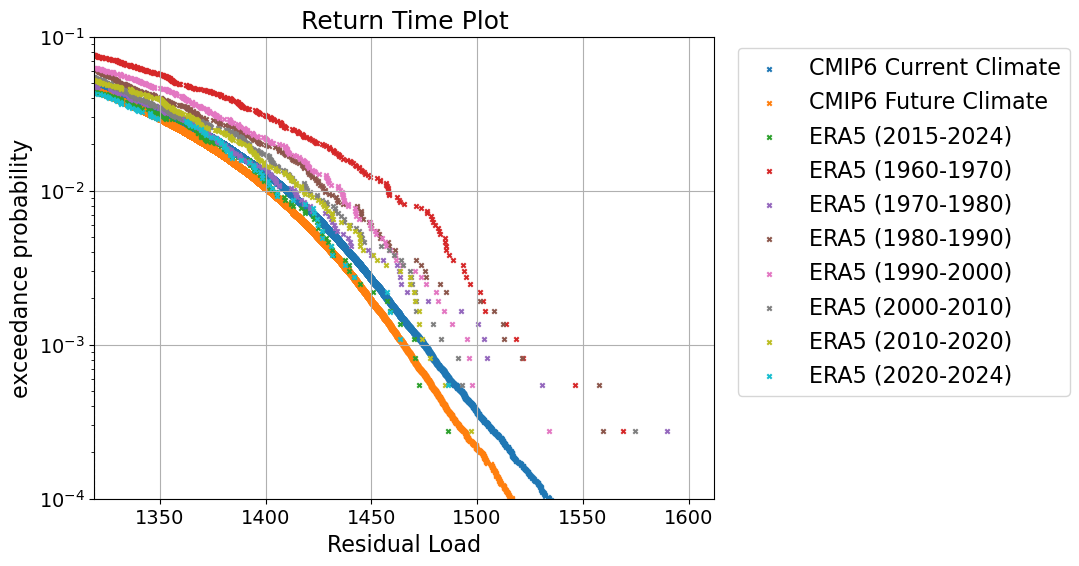

In [46]:
# This is only for the 1d values (but correct otherwise)

RLs = [res_load_ERA5, res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d]
labels = ['ERA5 (1960-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)']

RLs = [# res_load_ERA5, 
       res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
       res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
labels = [#'ERA5 (1960-2024)', 
          'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
          'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
          'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']


# RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
# labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-1990)', 'ERA5 (1990-2014)', 'ERA5 (2015-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()


# # Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()

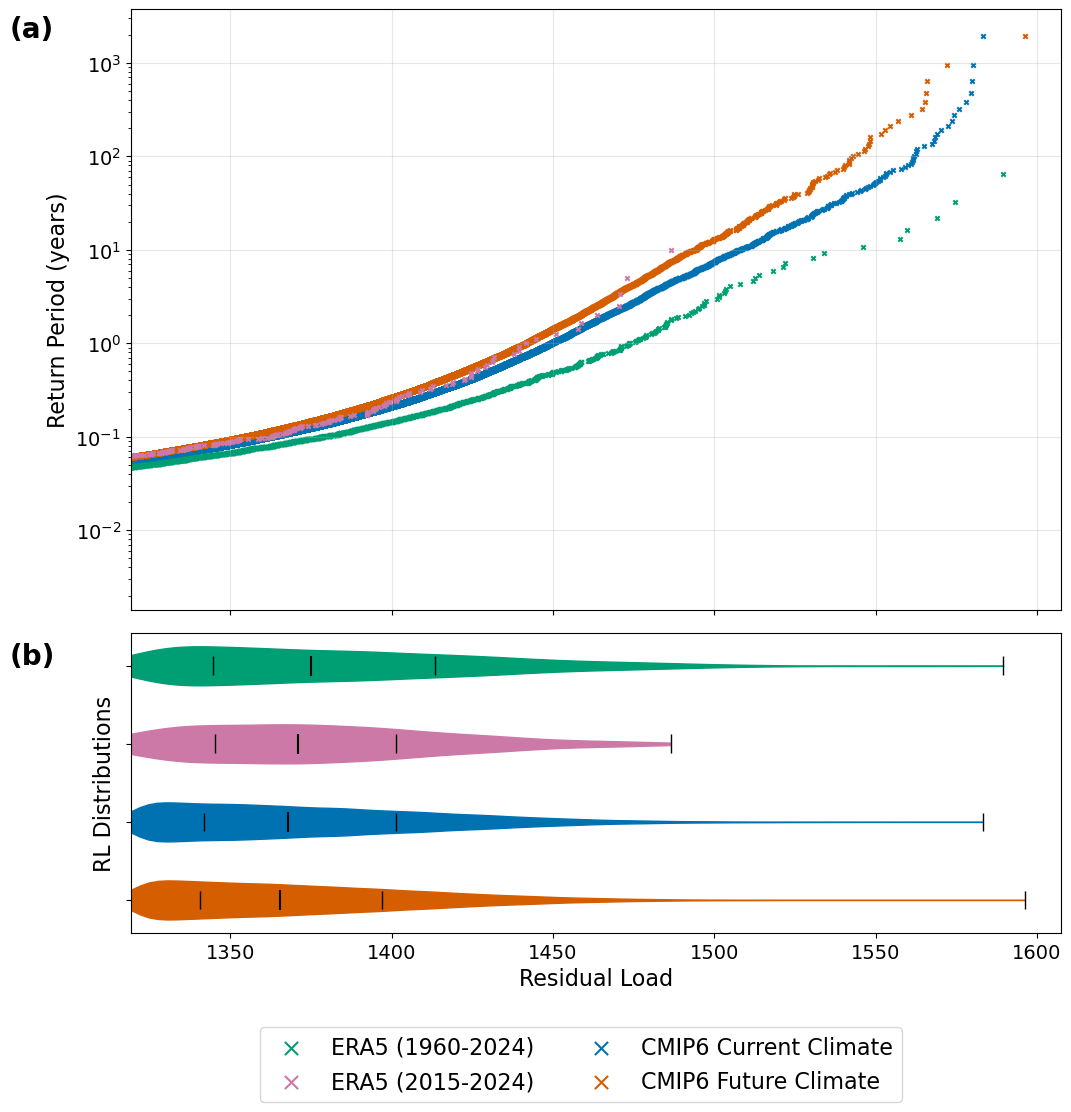

In [47]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})

RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]
labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-2024)', 'ERA5 (2015-2024)']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]


# Create figure with two vertically stacked axes
fig = plt.figure(figsize=(12, 12))
gs = GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.05)

ax_rt = fig.add_subplot(gs[0])
ax_violin = fig.add_subplot(gs[1], sharex=ax_rt)
colors = []
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(RLs)]
# Okabe-Ito colour-blind friendly palette
colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    # "#E69F00",  # orange
]
# -------------------------
# Return time plot
# -------------------------
for i, (res_load, label) in enumerate(zip(RLs, labels)):

    extremes = np.asarray(res_load)

    x = np.sort(extremes)
    m = np.arange(1, len(x) + 1)
    N = len(extremes)

    T = (1 / (1 - (m / (N + 1)))) / 365 

    sc = ax_rt.scatter(
        x,
        T,
        marker='x',
        color=colors[i],
        s=10,
        label=label
    )
    colors.append(sc.get_facecolor()[0])
threshold = np.float64(1319.138650687668)

ax_rt.axvline(
    threshold,
    color='gray',
    linestyle='--',
    linewidth=0.8
)

ax_rt.set_yscale('log')
ax_rt.set_xlim(
    threshold,
    np.float64(1596.223514139268) * 1.007
)

# ax_rt.set_ylabel('Exceedance Probability')
ax_rt.set_ylabel('Return Period (years)')

# ax_rt.set_title('Return Time Plot')
ax_rt.grid(alpha=0.3)

# ax_rt.legend(
#     loc='upper left',
#     bbox_to_anchor=(0, -0.65),
#     ncol=3
# )


# Remove the ax_rt.legend(...) call and replace with:
desired_order = [2, 3, 0, 1]
handles, labs = ax_rt.get_legend_handles_labels()
handles = [handles[i] for i in desired_order]
labs = [labs[i] for i in desired_order]
fig.legend(
    handles, labs,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),  # centered below the figure
    ncol=2,
    frameon=True,
    markerscale=3,
)
# -------------------------
# Horizontal violin plots
# -------------------------
RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]
labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-2024)', 'ERA5 (2015-2024)']
RLs = [res_load_ERA5, res_load_era5_15_24_1d, res_load_curr_clim_1d, res_load_fut_1d]
labels = ['ERA5 (1960-2024)', 'ERA5 (2015-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]
colors = [
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    # "#E69F00",  # orange
    "#0072B2",  # blue
    "#D55E00",  # vermillion
]

positions = np.arange(len(RLs_filt), 0, -1)

parts = ax_violin.violinplot(
    RLs_filt,
    positions=positions,
    vert=False,          # horizontal violins
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Width of the percentile markers
half_height = 0.12

for pos, data in zip(positions, RLs_filt):
    q25, med, q75 = np.percentile(data, [25, 50, 75])
    xmin = np.min(data)
    xmax = np.max(data)
    # 25th percentile
    ax_violin.vlines(
        q25, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # 75th percentile
    ax_violin.vlines(
        q75, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # Maximum
    ax_violin.vlines(
        xmax, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )


# Color the violins
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(1)

# Optional: color the median lines as well
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

parts
# ax_violin.axvline(
#     threshold,
#     color='gray',
#     linestyle='--',
#     linewidth=0.8
# )

ax_violin.set_yticks(positions)
# ax_violin.set_yticklabels(labels)
ax_violin.set_yticklabels("")

ax_violin.set_xlabel('Residual Load')
ax_violin.set_ylabel('RL Distributions')

# Hide top x tick labels
plt.setp(ax_rt.get_xticklabels(), visible=False)

# Panel labels
ax_rt.text(
    -0.13, 0.99, "(a)",
    transform=ax_rt.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

ax_violin.text(
    -0.13, 0.97, "(b)",
    transform=ax_violin.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

# plt.savefig(
#     '/home/onennecke/Code/Figures/return_time_plot_with_violins.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

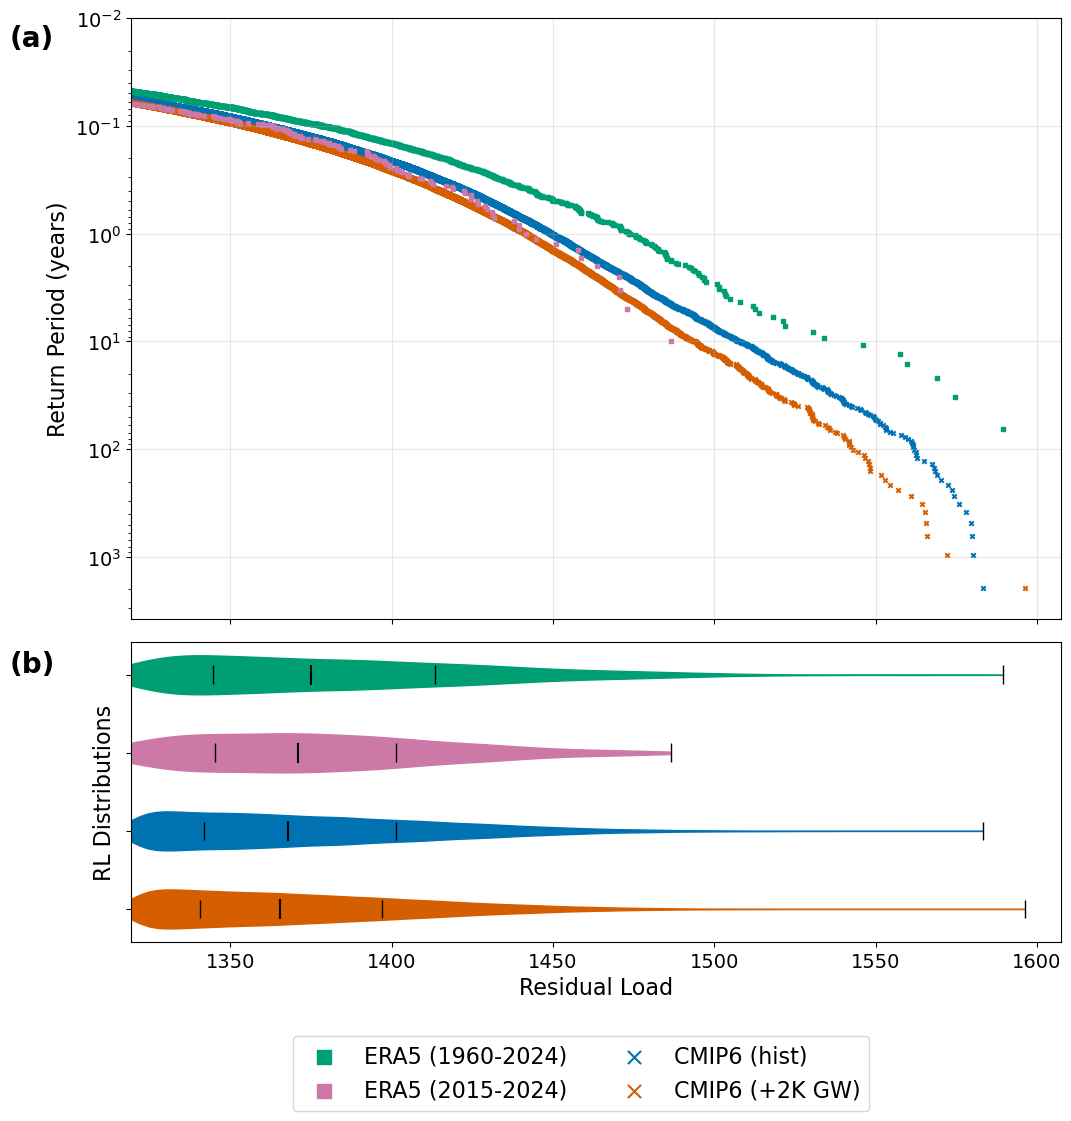

In [52]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})

RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]
labels = ['CMIP6 (hist)', 'CMIP6 (+2K GW)', 'ERA5 (1960-2024)', 'ERA5 (2015-2024)']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]


# Create figure with two vertically stacked axes
fig = plt.figure(figsize=(12, 12))
gs = GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.05)

ax_rt = fig.add_subplot(gs[0])
ax_violin = fig.add_subplot(gs[1], sharex=ax_rt)
colors = []
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(RLs)]
# Okabe-Ito colour-blind friendly palette
colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    # "#E69F00",  # orange
]
# -------------------------
# Return time plot
# -------------------------
for i, (res_load, label) in enumerate(zip(RLs, labels)):

    extremes = np.asarray(res_load)

    x = np.sort(extremes)
    m = np.arange(1, len(x) + 1)
    N = len(extremes)

    T = (1 / (1 - (m / (N + 1)))) / 365 

    if 'CMIP6' not in label:
        sc = ax_rt.scatter(
            x,
            T,
            marker='s',
            color=colors[i],
            s=10,
            label=label
        )
    else:
        sc = ax_rt.scatter(
            x,
            T,
            marker='x', # Other marker possibilities: 'o', 's', '^', 'D', '*', 
            color=colors[i],
            s=10,
            label=label
        )
    colors.append(sc.get_facecolor()[0])
threshold = np.float64(1319.138650687668)

ax_rt.axvline(
    threshold,
    color='gray',
    linestyle='--',
    linewidth=0.8
)

ax_rt.set_yscale('log')
ax_rt.set_xlim(
    threshold,
    np.float64(1596.223514139268) * 1.007
)
ax_rt.set_ylim(10**-2,None)

# ax_rt.set_ylabel('Exceedance Probability')
ax_rt.set_ylabel('Return Period (years)')
ax_rt.invert_yaxis()  # rare events (small prob) at the bottom

# ax_rt.set_title('Return Time Plot')
ax_rt.grid(alpha=0.3)

# ax_rt.legend(
#     loc='upper left',
#     bbox_to_anchor=(0, -0.65),
#     ncol=3
# )


# Remove the ax_rt.legend(...) call and replace with:
desired_order = [2, 3, 0, 1]
handles, labs = ax_rt.get_legend_handles_labels()
handles = [handles[i] for i in desired_order]
labs = [labs[i] for i in desired_order]
fig.legend(
    handles, labs,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),  # centered below the figure
    ncol=2,
    frameon=True,
    markerscale=3,
)
# -------------------------
# Horizontal violin plots
# -------------------------
RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]
labels = ['CMIP6 (hist)', 'CMIP6 (+2K GW)', 'ERA5 (1960-2024)', 'ERA5 (2015-2024)']
RLs = [res_load_ERA5, res_load_era5_15_24_1d, res_load_curr_clim_1d, res_load_fut_1d]
labels = ['ERA5 (1960-2024)', 'ERA5 (2015-2024)', 'CMIP6 (hist)', 'CMIP6 (+2K GW)']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]
colors = [
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    # "#E69F00",  # orange
    "#0072B2",  # blue
    "#D55E00",  # vermillion
]

positions = np.arange(len(RLs_filt), 0, -1)

parts = ax_violin.violinplot(
    RLs_filt,
    positions=positions,
    vert=False,          # horizontal violins
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Width of the percentile markers
half_height = 0.12

for pos, data in zip(positions, RLs_filt):
    q25, med, q75 = np.percentile(data, [25, 50, 75])
    xmin = np.min(data)
    xmax = np.max(data)
    # 25th percentile
    ax_violin.vlines(
        q25, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # 75th percentile
    ax_violin.vlines(
        q75, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # Maximum
    ax_violin.vlines(
        xmax, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )


# Color the violins
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(1)

# Optional: color the median lines as well
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

parts
# ax_violin.axvline(
#     threshold,
#     color='gray',
#     linestyle='--',
#     linewidth=0.8
# )

ax_violin.set_yticks(positions)
# ax_violin.set_yticklabels(labels)
ax_violin.set_yticklabels("")

ax_violin.set_xlabel('Residual Load')
ax_violin.set_ylabel('RL Distributions')

# Hide top x tick labels
plt.setp(ax_rt.get_xticklabels(), visible=False)

# Panel labels
ax_rt.text(
    -0.13, 0.99, "(a)",
    transform=ax_rt.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

ax_violin.text(
    -0.13, 0.97, "(b)",
    transform=ax_violin.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

# plt.savefig(
#     '/home/onennecke/Code/Figures/return_time_plot_with_violins_4.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

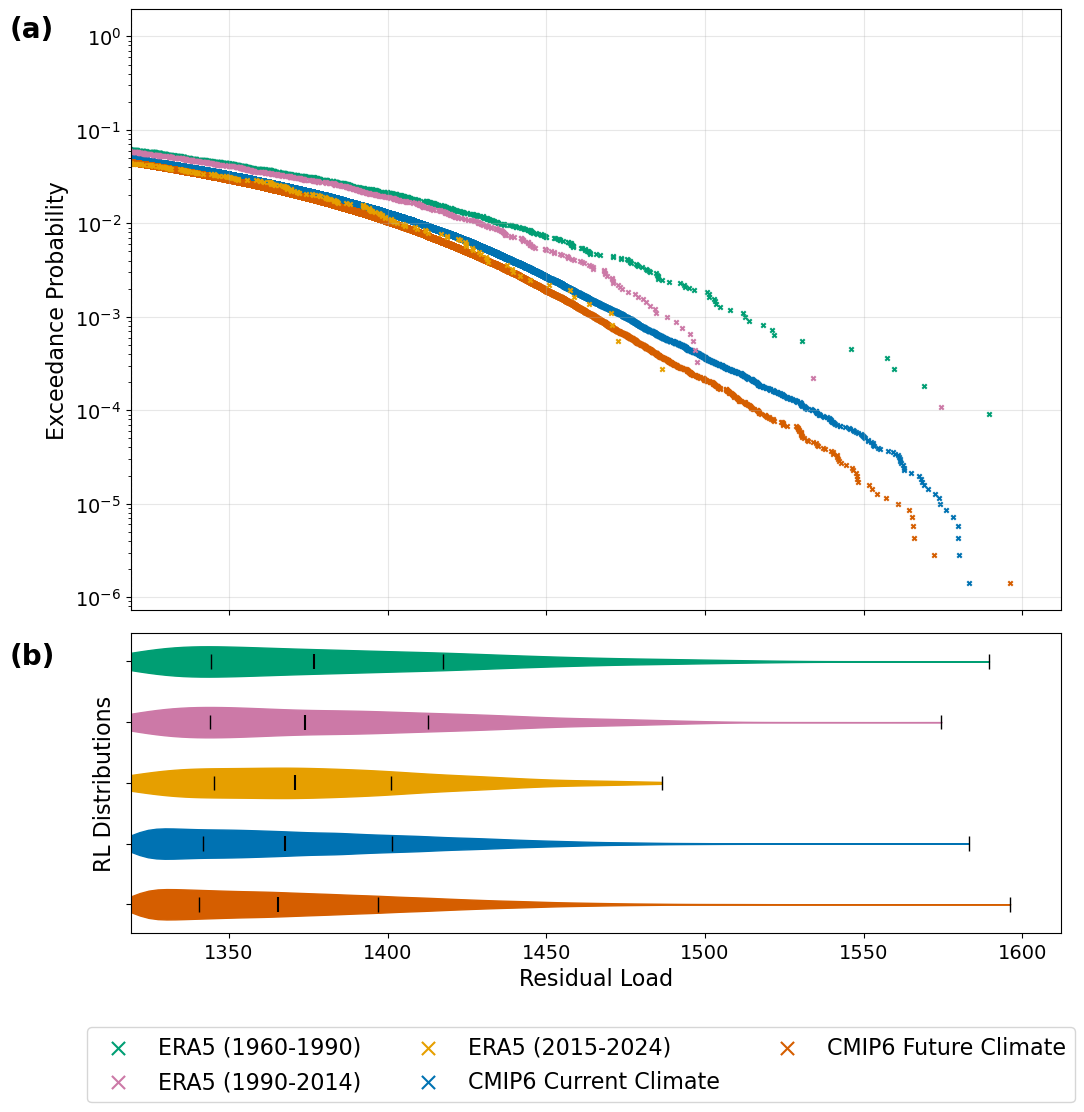

In [54]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})

RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-1990)', 'ERA5 (1990-2014)', 'ERA5 (2015-2024)']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]


# Create figure with two vertically stacked axes
fig = plt.figure(figsize=(12, 12))
gs = GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.05)

ax_rt = fig.add_subplot(gs[0])
ax_violin = fig.add_subplot(gs[1], sharex=ax_rt)
colors = []
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(RLs)]
# Okabe-Ito colour-blind friendly palette
colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#E69F00",  # orange
]
# -------------------------
# Return time plot
# -------------------------
for i, (res_load, label) in enumerate(zip(RLs, labels)):

    extremes = np.asarray(res_load)

    x = np.sort(extremes)
    m = np.arange(1, len(x) + 1)
    N = len(extremes)

    T = 1 - (m / (N + 1))

    sc = ax_rt.scatter(
        x,
        T,
        marker='x',
        color=colors[i],
        s=10,
        label=label
    )
    colors.append(sc.get_facecolor()[0])
threshold = np.float64(1319.138650687668)

ax_rt.axvline(
    threshold,
    color='gray',
    linestyle='--',
    linewidth=0.8
)

ax_rt.set_yscale('log')
ax_rt.set_xlim(
    threshold,
    np.float64(1596.223514139268) * 1.01
)

ax_rt.set_ylabel('Exceedance Probability')
# ax_rt.set_title('Return Time Plot')
ax_rt.grid(alpha=0.3)

# ax_rt.legend(
#     loc='upper left',
#     bbox_to_anchor=(0, -0.65),
#     ncol=3
# )


# Remove the ax_rt.legend(...) call and replace with:
desired_order = [2, 3, 4, 0, 1]
handles, labs = ax_rt.get_legend_handles_labels()
handles = [handles[i] for i in desired_order]
labs = [labs[i] for i in desired_order]
fig.legend(
    handles, labs,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),  # centered below the figure
    ncol=3,
    frameon=True,
    markerscale=3,
)
# -------------------------
# Horizontal violin plots
# -------------------------
RLs = [res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d, res_load_curr_clim_1d, res_load_fut_1d]
labels = ['ERA5 (1960-1990)', 'ERA5 (1990-2014)', 'ERA5 (2015-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]
colors = [
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#E69F00",  # orange
    "#0072B2",  # blue
    "#D55E00",  # vermillion
]

positions = np.arange(len(RLs_filt), 0, -1)

parts = ax_violin.violinplot(
    RLs_filt,
    positions=positions,
    vert=False,          # horizontal violins
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Width of the percentile markers
half_height = 0.12

for pos, data in zip(positions, RLs_filt):
    q25, med, q75 = np.percentile(data, [25, 50, 75])
    xmin = np.min(data)
    xmax = np.max(data)
    # 25th percentile
    ax_violin.vlines(
        q25, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # 75th percentile
    ax_violin.vlines(
        q75, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # Maximum
    ax_violin.vlines(
        xmax, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )


# Color the violins
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(1)

# Optional: color the median lines as well
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)

parts
# ax_violin.axvline(
#     threshold,
#     color='gray',
#     linestyle='--',
#     linewidth=0.8
# )

ax_violin.set_yticks(positions)
# ax_violin.set_yticklabels(labels)
ax_violin.set_yticklabels("")

ax_violin.set_xlabel('Residual Load')
ax_violin.set_ylabel('RL Distributions')

# Hide top x tick labels
plt.setp(ax_rt.get_xticklabels(), visible=False)

# Panel labels
ax_rt.text(
    -0.13, 0.99, "(a)",
    transform=ax_rt.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

ax_violin.text(
    -0.13, 0.97, "(b)",
    transform=ax_violin.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

# plt.savefig(
#     '/home/onennecke/Code/Figures/return_time_plot_with_violins.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [55]:
RLs = [res_load_curr_clim_1d, res_load_fut_1d]#, res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]


for i, res_load in enumerate(RLs):

    extremes = np.asarray(res_load)

    x = np.sort(extremes)
    m = np.arange(1, len(x) + 1) # m is the rank of the value in the sorted array
    N = len(extremes)

    T = 1 - (m / (N + 1)) # T is the exceedance probability
    
    # Find out which T values correspond to the value
    value = np.float64(1507.8521587109076)
    value_index = np.where(x > value)[0][0]  # index of the first value greater than value
    value_T = T[value_index]
    print(f"Value: {value}, Corresponding T: {value_T}, Return Period in days: {1/value_T} in years: {(1/value_T)/365}")
    
    
    # Find out which residual load values correspond to a return period of 1 year (T = 1/365)
    target_T = 1/(365 * 10)
    target_index = np.where(T <= target_T)[0][0]  # index of the first T value less than or equal to target_T
    target_value = x[target_index]
    print(f"Target T: {target_T}, Corresponding Residual Load: {target_value}")


Value: 1507.8521587109076, Corresponding T: 0.0002725452731945355, Return Period in days: 3669.115183246003 in years: 10.052370365057543
Target T: 0.000273972602739726, Corresponding Residual Load: 1507.8521587109076
Value: 1507.8521587109076, Corresponding T: 0.00015268243053301322, Return Period in days: 6549.542056076835 in years: 17.94395083856667
Target T: 0.000273972602739726, Corresponding Residual Load: 1493.9903565345453


In [57]:
RLs = [res_load_curr_clim_1d, res_load_fut_1d]#, res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]


for i, res_load in enumerate(RLs):

    extremes = np.asarray(res_load)

    x = np.sort(extremes)
    m = np.arange(1, len(x) + 1) # m is the rank of the value in the sorted array
    N = len(extremes)

    T = 1 - (m / (N + 1)) # T is the exceedance probability
    
    # Find out which T values correspond to the value
    value = np.float64(1449.4453815207578)
    value_index = np.where(x > value)[0][0]  # index of the first value greater than value
    value_T = T[value_index]
    print(f"Value: {value}, Corresponding T: {value_T}, Return Period in days: {1/value_T} in years: {(1/value_T)/365}")
    
    
    # Find out which residual load values correspond to a return period of 1 year (T = 1/365)
    target_T = 1/(365 )
    target_index = np.where(T <= target_T)[0][0]  # index of the first T value less than or equal to target_T
    target_value = x[target_index]
    print(f"Target T: {target_T}, Corresponding Residual Load: {target_value}")


Value: 1449.4453815207578, Corresponding T: 0.0027382951793732957, Return Period in days: 365.1907243355943 in years: 1.0005225324262859
Target T: 0.0027397260273972603, Corresponding Residual Load: 1449.4453815207578
Value: 1449.4453815207578, Corresponding T: 0.0019734560881049523, Return Period in days: 506.7252349963705 in years: 1.3882883150585492
Target T: 0.0027397260273972603, Corresponding Residual Load: 1441.6143960190102


In [58]:
0.05*365

18.25

In [108]:
res_load_curr_clim_7d

<xarray.DataArray 'Residual_load' (ESM_run: 192, time: 3650)> Size: 6MB
array([[          nan,           nan,           nan, ...,  817.63199095,
         847.27327767,  863.51671488],
       [          nan,           nan,           nan, ...,  628.96065893,
         598.6270437 ,  552.29114253],
       [          nan,           nan,           nan, ..., 1167.1525813 ,
        1206.35170522, 1121.48393708],
       ...,
       [          nan,           nan,           nan, ...,  840.13255382,
         759.03898423,  677.96400752],
       [          nan,           nan,           nan, ...,  740.44251843,
         771.67281998,  825.87270357],
       [          nan,           nan,           nan, ..., 1240.66629851,
        1306.93995862, 1309.0679038 ]])
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
    winter_season  (time) <U5 73kB '14/15' '14/15' '14/15' ... '24/25' '24/25'

In [109]:
res_load_curr_clim_1d

array([ 609.48011372,  793.41464988,  907.1603086 , ..., 1306.70204962,
       1506.6195729 , 1319.56557544])

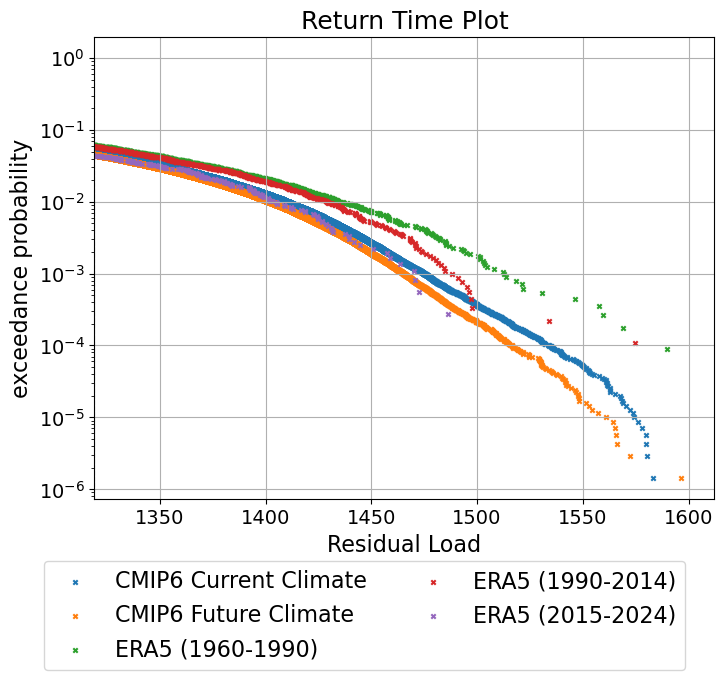

In [42]:
# This is only for the 1d values (but correct otherwise)

RLs = [res_load_ERA5, res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d]
labels = ['ERA5 (1960-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)']

RLs = [# res_load_ERA5, 
       res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
       res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
labels = [#'ERA5 (1960-2024)', 
          'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
          'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
          'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']


RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-1990)', 'ERA5 (1990-2014)', 'ERA5 (2015-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(-0.1, -0.11), ncol=2)
plt.grid(True)
plt.savefig('/home/onennecke/Code/Figures/return_time_plot_exceedance_prob.png', dpi=300, bbox_inches='tight')
plt.show()


# Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()

In [26]:
res_load_fut

<xarray.DataArray 'Residual_load' (ESM_run: 192, time: 3650)> Size: 6MB
array([[1221.20013817, 1071.59187726, 1250.71236328, ..., 1124.18602803,
        1314.31349002, 1291.64656601],
       [1236.05905651, 1028.26014001,  859.23223506, ..., 1200.41834566,
        1364.94718233, 1281.12595676],
       [ 958.52142067,  762.15764943,  424.02704545, ...,  993.32481832,
         955.29524753,  721.85881236],
       ...,
       [  -6.01077866,  382.37037722,  319.39666533, ...,  948.5305033 ,
         523.1708532 ,  580.68592875],
       [1544.47081279, 1272.66468121,  766.56365913, ...,  989.08750978,
        1239.88797735,  934.47109452],
       [ 131.16803645,  280.03751942,  555.75631081, ..., 1106.66151732,
         674.92395871,   71.73037994]])
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
    winter_season  (time) <U5 73kB '38/39' '38/39' '38/39' ... '48/49' '48/49'

In [35]:
len(res_load_fut.where(res_load_fut.ESM == 'ACCESS-CM2', drop=True).values.ravel())/3

3650.0

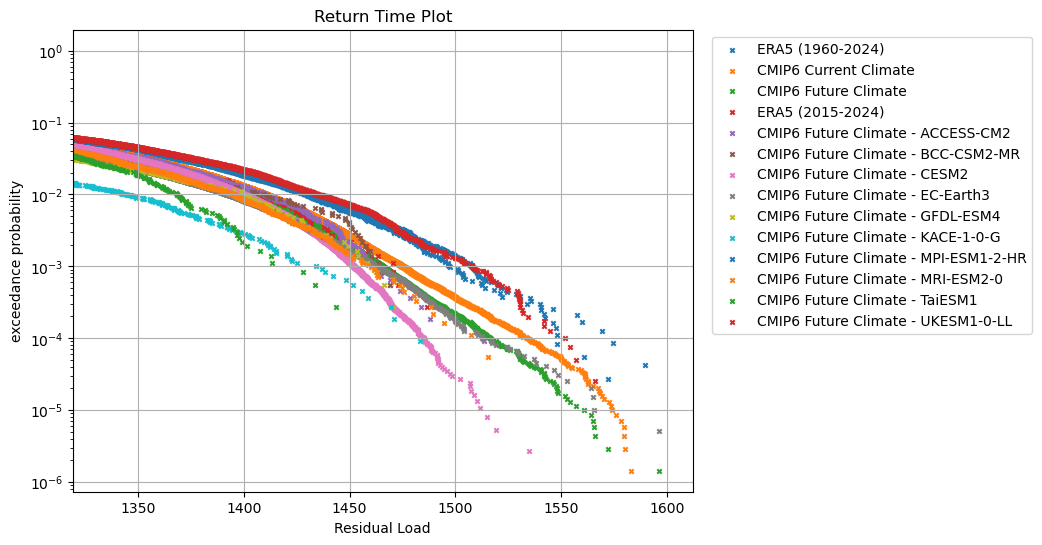

In [38]:
# This is only for the 1d values (but correct otherwise)

RLs = [res_load_ERA5, res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d]
labels = ['ERA5 (1960-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)']

# Plot
plt.figure(figsize=(8,6))

for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1

for esm in np.unique(res_load_fut.ESM):

    # Example: extreme residual load values
    extremes = res_load_fut.where(res_load_fut.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Future Climate - {esm}'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()

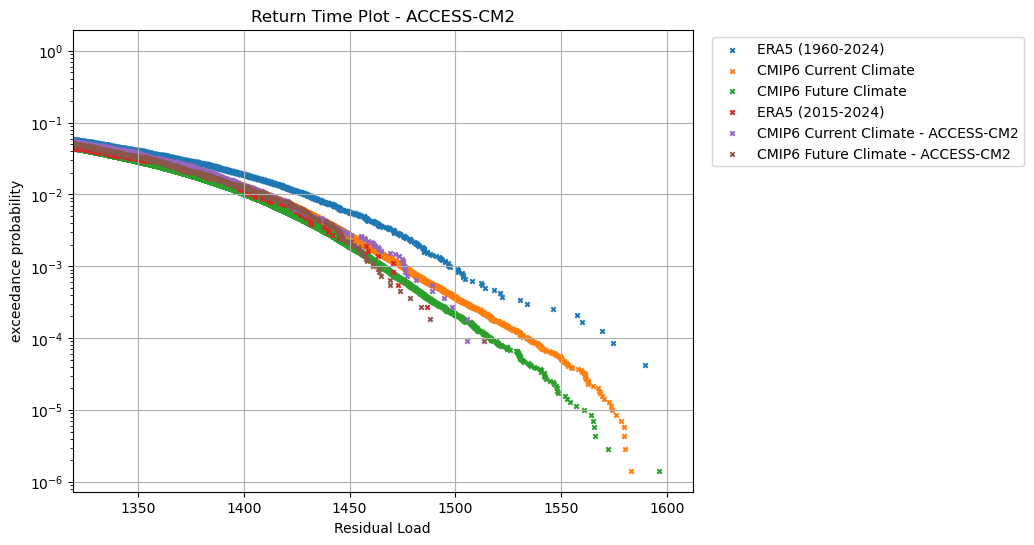

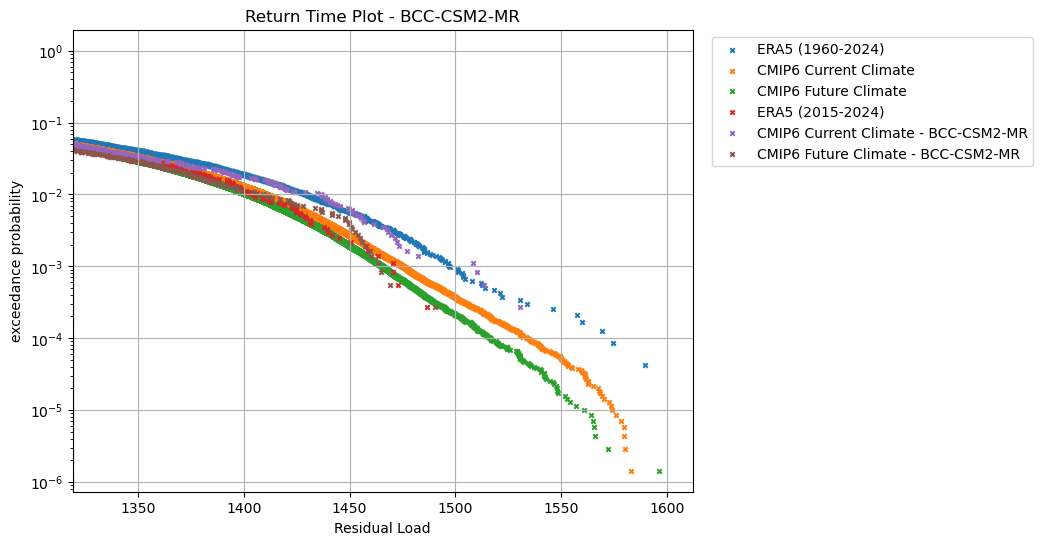

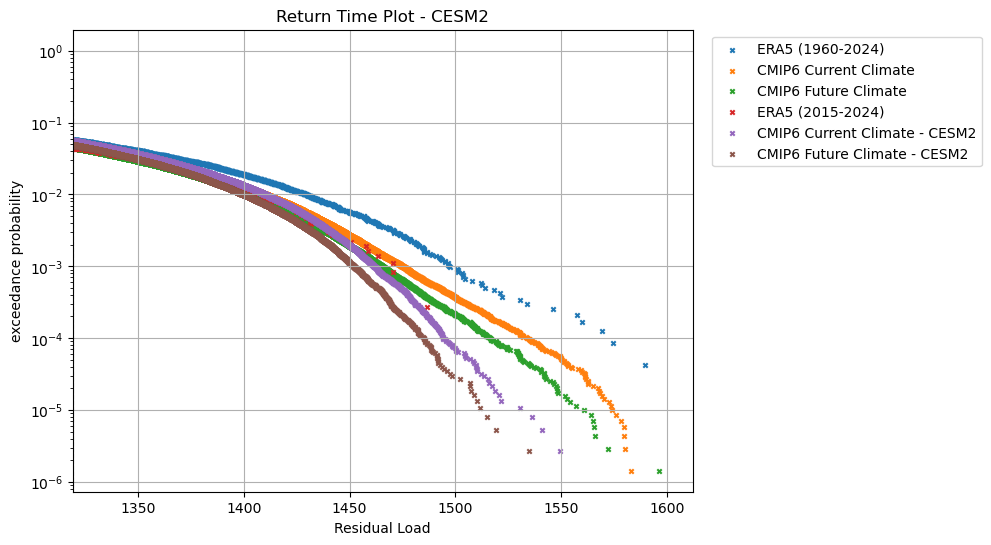

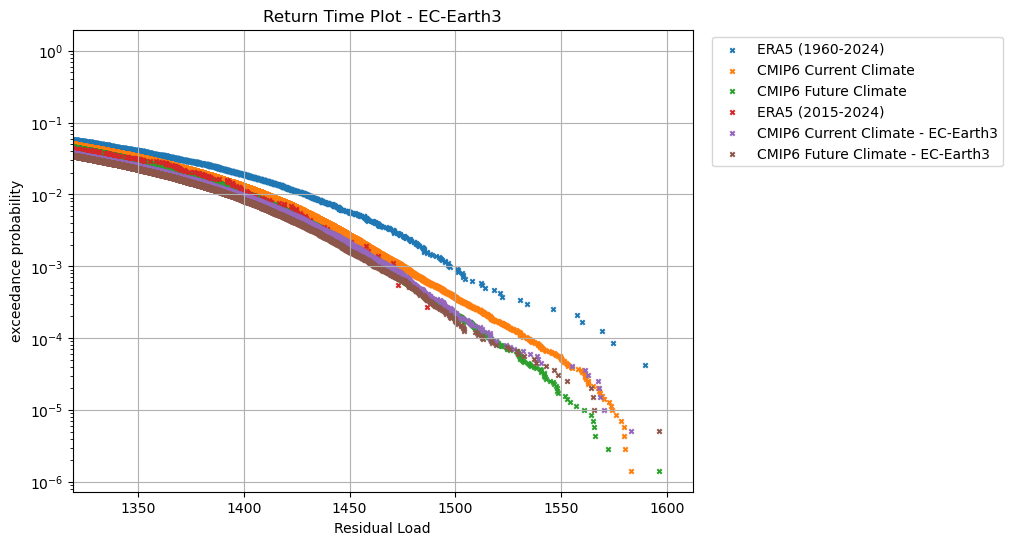

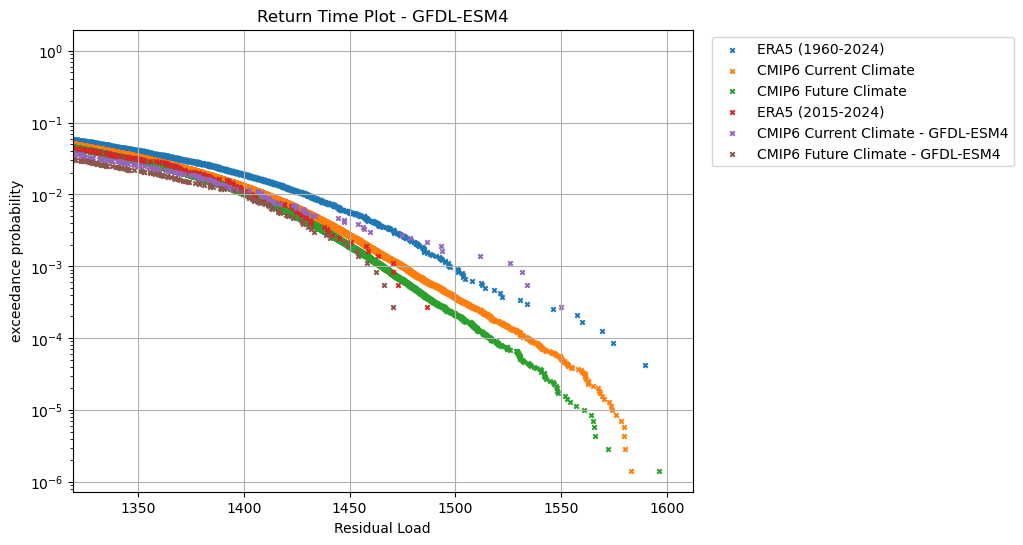

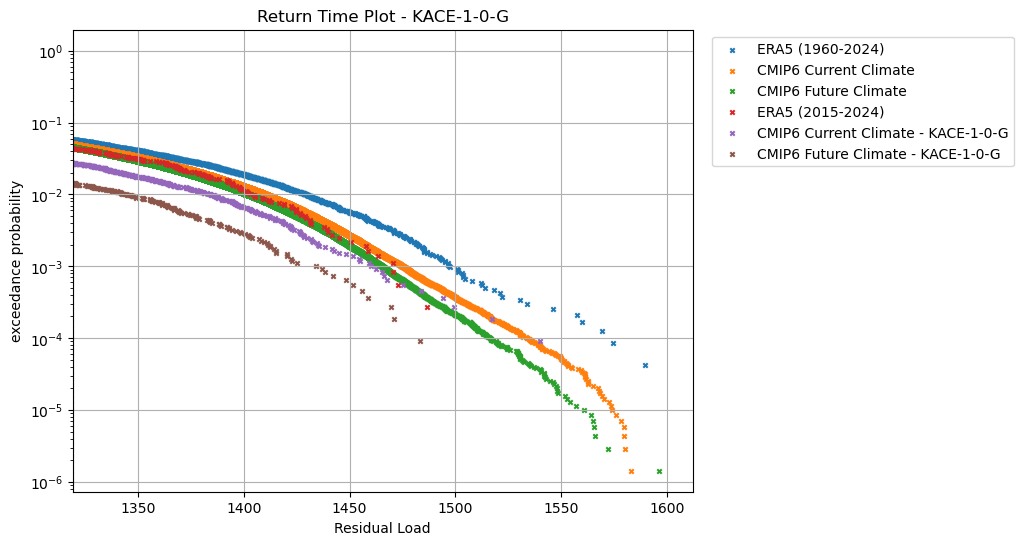

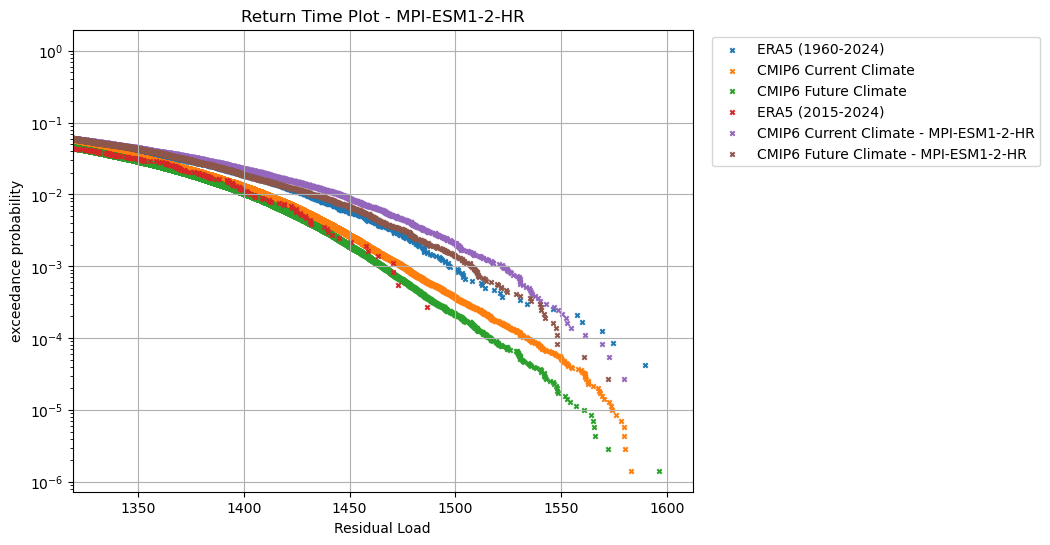

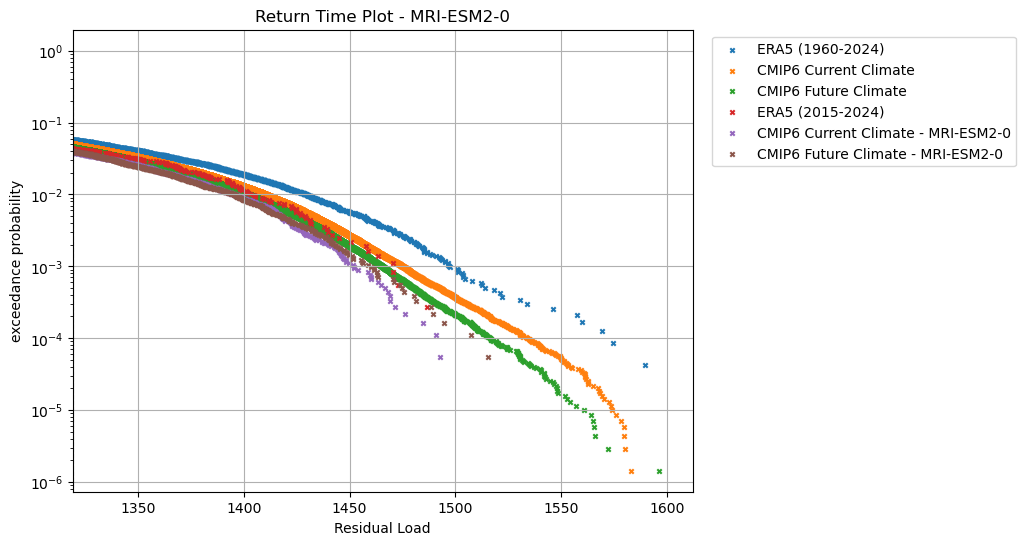

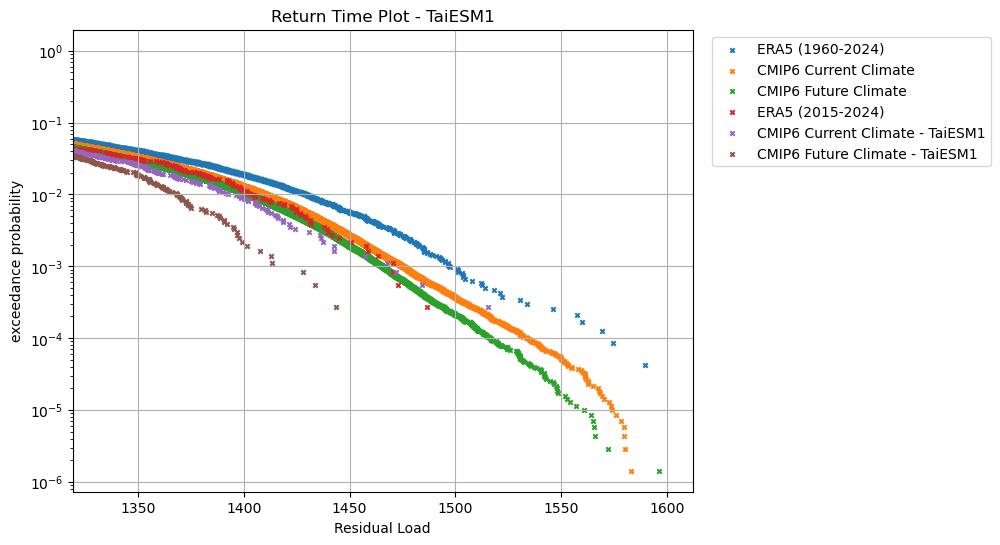

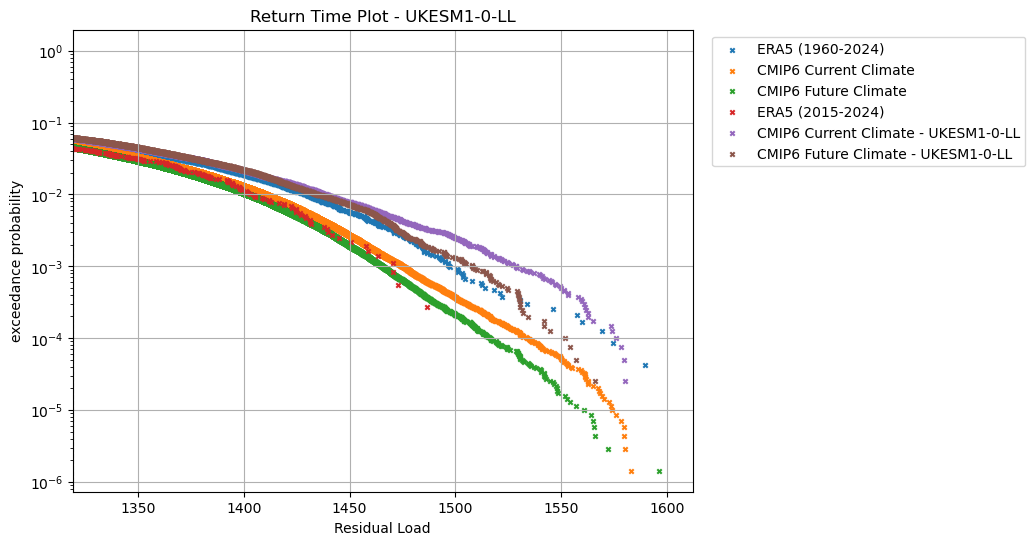

In [40]:
# This is only for the 1d values (but correct otherwise)

RLs = [res_load_ERA5, res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d]
labels = ['ERA5 (1960-2024)', 'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)']


for esm in np.unique(res_load_fut.ESM):
    # Plot
    plt.figure(figsize=(8,6))

    for res_load, label in zip(RLs, labels):

        # Example: extreme residual load values
        extremes = res_load # your event values

        # Sort ascending
        x = np.sort(extremes)

        # Rank
        m = np.arange(1, len(x) + 1)

        # Total observation period (important!)
        N = len(extremes)  # OR number of years, depending on method

        # Return period
        # T = (N + 1) / (N + 1 - m)
        T = (1 - (m/(N+1)))  # equivalent, more direct formula
            


        plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1



    extremes = res_load_curr_clim.where(res_load_curr_clim.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Current Climate - {esm}'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
    
    extremes = res_load_fut.where(res_load_fut.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Future Climate - {esm}'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
    plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
    plt.yscale('log')
    # plt.xscale('log')
    plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
    # plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

    # plt.ylim(1e-4, 1e-1)
    plt.ylabel('exceedance probability')
    plt.xlabel('Residual Load')
    plt.title(f'Return Time Plot - {esm}')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.grid(True)
    plt.show()

In [63]:
# np.max(res_load_fut.values.ravel().max(), res_load_curr_clim.values.ravel().max())
max(res_load_fut.values.ravel().max(), res_load_curr_clim.values.ravel().max())

np.float64(1596.223514139268)

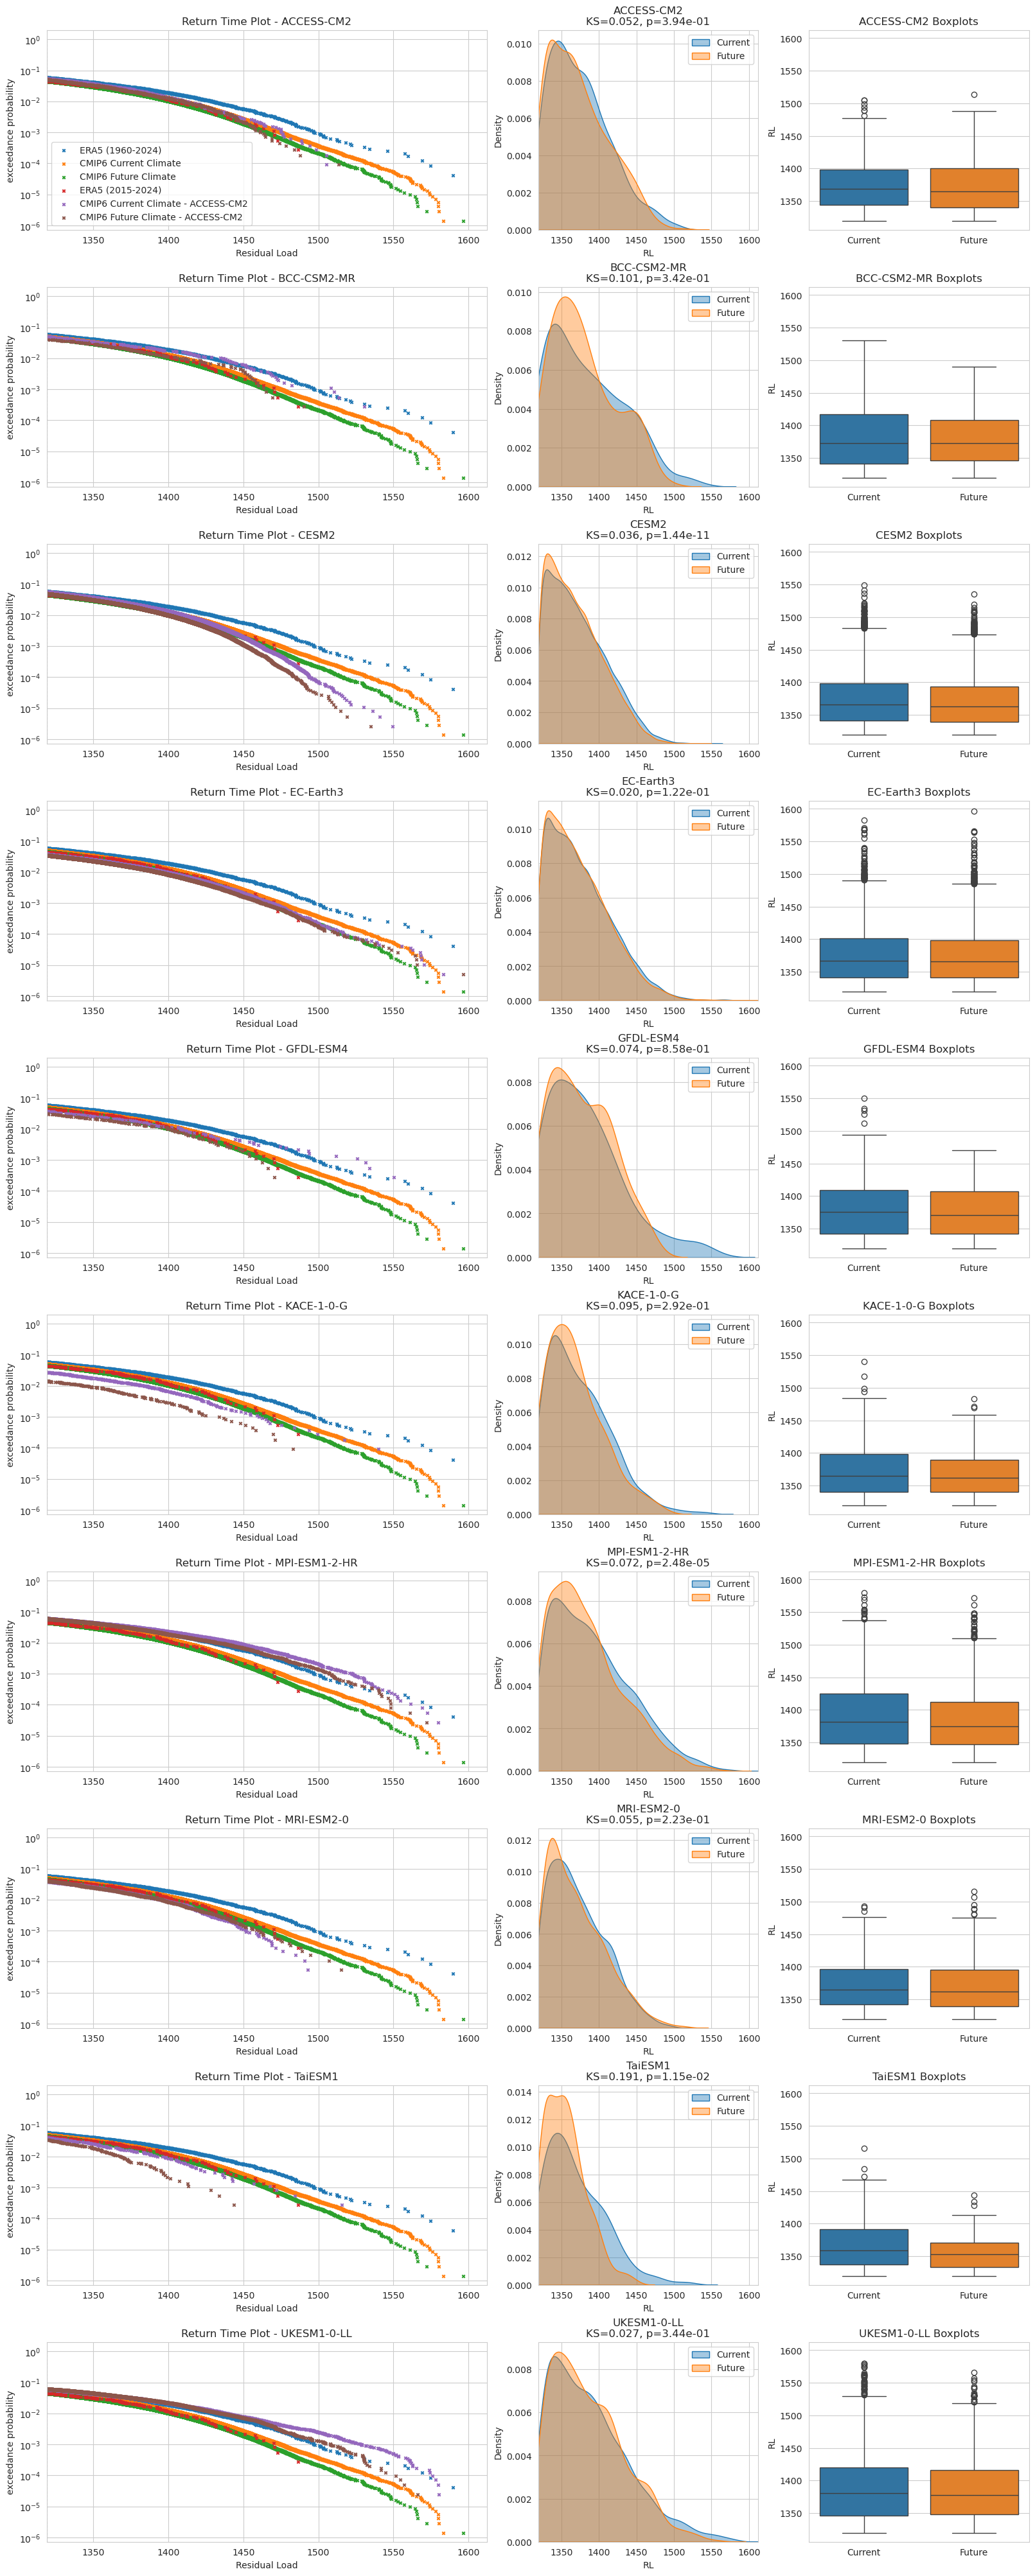

In [ ]:

sns.set_style("whitegrid")

n = len(np.unique(res_load_fut.ESM))

fig, axes = plt.subplots(
    nrows=n,
    ncols=3,
    figsize=(16, 4 * n),
    width_ratios=[2, 1, 1],
    constrained_layout=True,
    sharex=False,
    sharey=False
)
threshold = np.float64(1319.138650687668)
maximum = max(res_load_fut.values.ravel().max(), res_load_curr_clim.values.ravel().max())


for i, esm in enumerate(np.unique(res_load_fut.ESM)):


    cur_all = res_load_curr_clim.where(res_load_curr_clim.ESM == esm, drop=True).values.ravel()
    cur = cur_all[cur_all > threshold]
    fut_all = res_load_fut.where(res_load_fut.ESM == esm, drop=True).values.ravel() 
    fut = fut_all[fut_all > threshold]

    # -------------------------
    # Returntime plot
    # -------------------------
    ax_1 = axes[i, 0]
    for res_load, label in zip(RLs, labels):

        # Example: extreme residual load values
        extremes = res_load # your event values

        # Sort ascending
        x = np.sort(extremes)

        # Rank
        m = np.arange(1, len(x) + 1)

        # Total observation period (important!)
        N = len(extremes)  # OR number of years, depending on method

        # Return period
        # T = (N + 1) / (N + 1 - m)
        T = (1 - (m/(N+1)))  # equivalent, more direct formula
            


        ax_1.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1

    extremes = res_load_curr_clim.where(res_load_curr_clim.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Current Climate'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    ax_1.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
    
    extremes = res_load_fut.where(res_load_fut.ESM == esm, drop=True).values.ravel() 
    label = f'CMIP6 Future Climate'
    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
    ax_1.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
    ax_1.vlines(threshold, ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
    ax_1.set_yscale('log')
    # ax_1.xscale('log')
    ax_1.set_xlim(threshold, maximum*1.01)
    # ax_1.set_xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

    # ax_1.set_ylim(1e-4, 1e-1)
    ax_1.set_ylabel('exceedance probability')
    ax_1.set_xlabel('Residual Load')
    ax_1.set_title(f'Return Time Plot - {esm}')
    # ax_1.legend(loc='upper left', bbox_to_anchor=(0.5, -0.41))
    if i == 0:
        ax_1.legend(loc='lower left')
    ax_1.grid(True)

    

    # -------------------------
    # KDE plot
    # -------------------------
    ax_2 = axes[i, 1]

    sns.kdeplot(cur, ax=ax_2, label='Current', fill=True, alpha=0.4)
    sns.kdeplot(fut, ax=ax_2, label='Future', fill=True, alpha=0.4)
    # ax_2.set_xlim(0, 25)
    # metrics
    ks_stat, ks_p = ks_2samp(cur, fut)

    ax_2.set_xlim(threshold, maximum*1.01)
    ax_2.set_title(f"{esm}\nKS={ks_stat:.3f}, p={ks_p:.2e}")
    ax_2.set_xlabel('RL')
    ax_2.legend()

    # -------------------------
    # Boxplot
    # -------------------------
    ax3 = axes[i, 2]

    sns.boxplot(
        data=[cur, fut],
        ax=ax3
    )
    ax3.set_ylim(threshold*0.99, maximum*1.01)
    ax3.set_xticks([0, 1])
    ax3.set_xticklabels(['Current', 'Future'])
    ax3.set_title(f"{esm} Boxplots")
    ax3.set_ylabel('RL')

plt.show()

In [43]:
10**5 * 7 / 365

# 365 * 10* 192

1917.8082191780823

In [ ]:
res_load_ERA5_7d
LEE_7_ERA5['RL_cumulative']
LEE_7_CMIP['RL_cumulative']
LEE_7_fut['RL_cumulative']
LEE_7_ERA5_15_24['RL_cumulative']

0     9584.428025
1     9411.793076
2     9806.489237
3     9294.940874
4     9380.513610
         ...     
72    9501.744800
73    9364.921762
74    9892.719655
75    9299.234201
76    9494.402708
Name: RL_cumulative, Length: 77, dtype: float64

In [89]:
LEE_7_ERA5_15_24

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season
2001,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000001,18,24,19,7,1439.293940,1364.007977,66.664621,9548.055836,2002,ERA5_week,ERA5_hist_week,2015,19,14/15
2002,2016-01-15,2016-01-21,2016-01-15 00:00:00.000000006,379,385,385,7,1431.707705,1366.706032,43.255350,9566.942225,2003,ERA5_week,ERA5_hist_week,2016,15,15/16
2003,2016-12-12,2016-12-18,2016-12-12 00:00:00.000000000,710,716,710,7,1394.297059,1328.784991,68.631400,9301.494934,2004,ERA5_week,ERA5_hist_week,2016,346,16/17
2004,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000004,748,754,752,7,1470.397466,1394.847373,60.301206,9763.931611,2005,ERA5_week,ERA5_hist_week,2017,19,16/17
2005,2019-01-19,2019-01-25,2019-01-19 00:00:00.000000005,1478,1484,1483,7,1470.620258,1357.392115,97.549782,9501.744807,2006,ERA5_week,ERA5_hist_week,2019,19,18/19
2006,2020-11-26,2020-12-02,2020-11-26 00:00:00.000000006,2154,2160,2160,7,1395.032961,1337.845965,54.717352,9364.921757,2007,ERA5_week,ERA5_hist_week,2020,330,20/21
2007,2022-12-10,2022-12-16,2022-12-10 00:00:00.000000006,2898,2904,2904,7,1486.441387,1413.245666,35.261726,9892.719664,2008,ERA5_week,ERA5_hist_week,2022,344,22/23
2008,2023-01-22,2023-01-28,2023-01-22 00:00:00.000000004,2941,2947,2945,7,1388.191698,1328.462027,73.743845,9299.234188,2009,ERA5_week,ERA5_hist_week,2023,22,22/23
2009,2023-11-27,2023-12-03,2023-11-27 00:00:00.000000005,3250,3256,3255,7,1463.499258,1356.343244,103.949461,9494.402705,2010,ERA5_week,ERA5_hist_week,2023,331,23/24


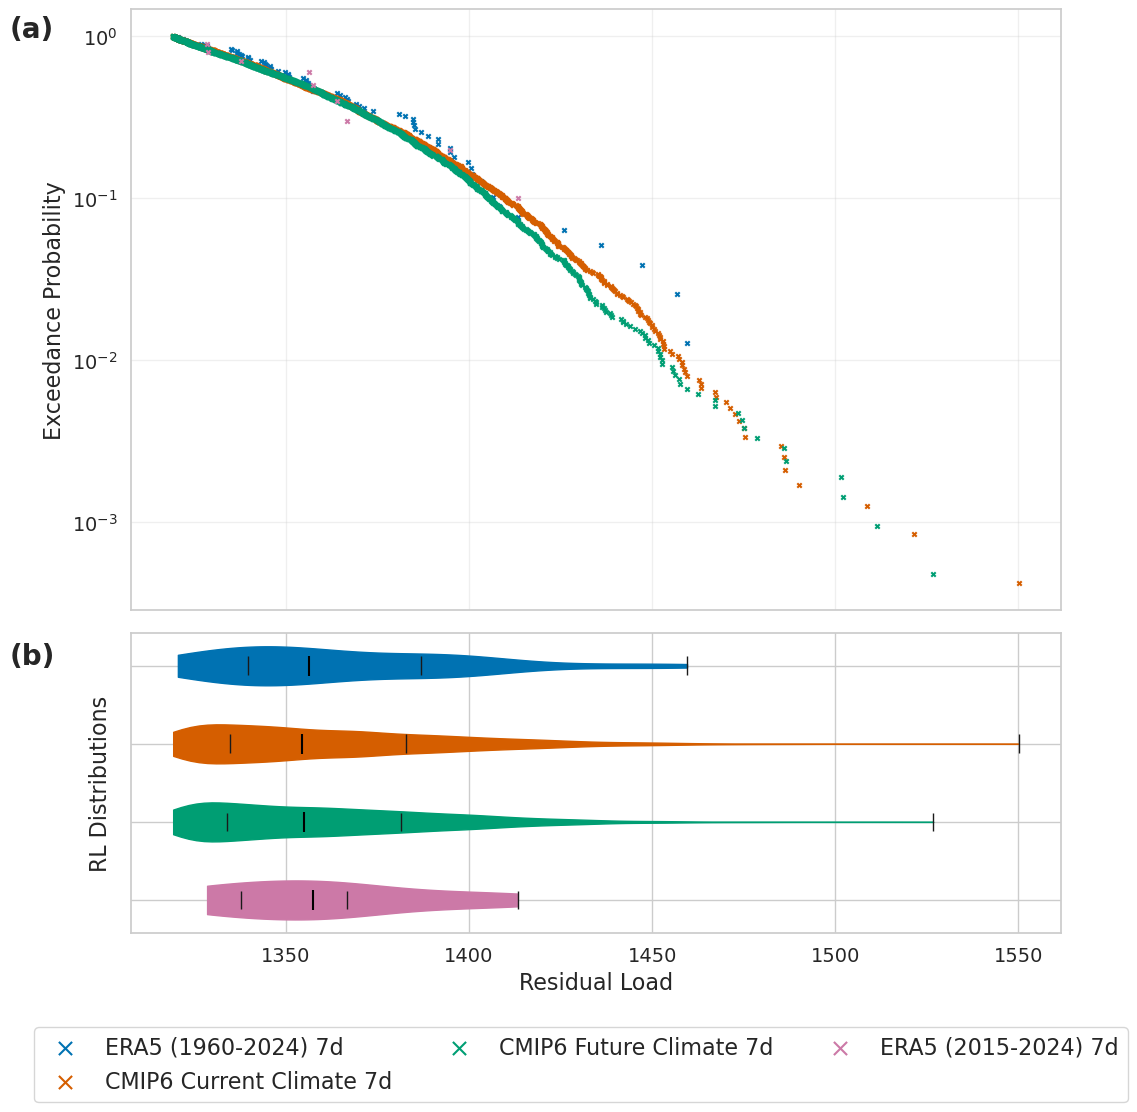

In [79]:


mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})
RLs = [LEE_7_ERA5['RL_cumulative'], LEE_7_CMIP['RL_cumulative'], LEE_7_fut['RL_cumulative'], LEE_7_ERA5_15_24['RL_cumulative']]
RLs = [LEE_7_ERA5['RL_mean'], LEE_7_CMIP['RL_mean'], LEE_7_fut['RL_mean'], LEE_7_ERA5_15_24['RL_mean']]

labels = ['ERA5 (1960-2024) 7d', 'CMIP6 Current Climate 7d', 'CMIP6 Future Climate 7d', 'ERA5 (2015-2024) 7d']

# RLs = [res_load_curr_clim_7d.values.ravel(), res_load_fut_7d.values.ravel(), res_load_ERA5_1960_1990, res_load_ERA5_1990_2014, res_load_era5_15_24_1d]
# labels = ['CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (1960-1990)', 'ERA5 (1990-2014)', 'ERA5 (2015-2024)']
RLs_filt = [rl[rl > np.float64(1319.138650687668)] for rl in RLs]


# Create figure with two vertically stacked axes
fig = plt.figure(figsize=(12, 12))
gs = GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.05)

ax_rt = fig.add_subplot(gs[0])
ax_violin = fig.add_subplot(gs[1], sharex=ax_rt)
colors = []
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(RLs)]
# Okabe-Ito colour-blind friendly palette
colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    # "#E69F00",  # orange
]
# -------------------------
# Return time plot
# -------------------------
# for i, (res_load, label) in enumerate(zip(RLs, labels)):

#     extremes = np.asarray(res_load)

#     x = np.sort(extremes)
#     m = np.arange(1, len(x) + 1)
#     N = len(extremes)

#     T = 1 - (m / (N + 1))

#     sc = ax_rt.scatter(
#         x,
#         T,
#         marker='x',
#         color=colors[i],
#         s=10,
#         label=label
#     )
#     colors.append(sc.get_facecolor()[0])
    
for i, (res_load, label) in enumerate(zip(RLs, labels)):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # event rate
    if ('ERA5' in label) and ('15' in label):
        n_years = 10  # ERA5 covers 2015-2024 for this subset
    elif 'ERA5' in label:
        n_years = 65  # ERA5 covers 1960-2024
    else:
        n_years = 10 * 192  # 10 years for each of the 192 runs
    
    lambda_ = N / n_years
    
    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        
    sc = ax_rt.scatter(
        x,
        T,
        marker='x',
        color=colors[i],
        s=10,
        label=label
    )
    colors.append(sc.get_facecolor()[0])

    # plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1    



threshold = np.float64(1319.138650687668)

# ax_rt.axvline(
#     threshold,
#     color='gray',
#     linestyle='--',
#     linewidth=0.8
# )

ax_rt.set_yscale('log')
# ax_rt.set_xlim(
#     threshold,
#     np.float64(1596.223514139268) * 1.01
# )

ax_rt.set_ylabel('Exceedance Probability')
# ax_rt.set_title('Return Time Plot')
ax_rt.grid(alpha=0.3)

# ax_rt.legend(
#     loc='upper left',
#     bbox_to_anchor=(0, -0.65),
#     ncol=3
# )


# Remove the ax_rt.legend(...) call and replace with:
desired_order = [0, 1, 2, 3]
handles, labs = ax_rt.get_legend_handles_labels()
handles = [handles[i] for i in desired_order]
labs = [labs[i] for i in desired_order]
fig.legend(
    handles, labs,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),  # centered below the figure
    ncol=3,
    frameon=True,
    markerscale=3,
)
# -------------------------
# Horizontal violin plots
# -------------------------

positions = np.arange(len(RLs_filt), 0, -1)

parts = ax_violin.violinplot(
    RLs_filt,
    positions=positions,
    vert=False,          # horizontal violins
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Width of the percentile markers
half_height = 0.12

for pos, data in zip(positions, RLs_filt):
    q25, med, q75 = np.percentile(data, [25, 50, 75])
    xmin = np.min(data)
    xmax = np.max(data)
    # 25th percentile
    ax_violin.vlines(
        q25, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # 75th percentile
    ax_violin.vlines(
        q75, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )
    # Maximum
    ax_violin.vlines(
        xmax, pos-half_height, pos+half_height,
        color='k', linewidth=1
    )


# Color the violins
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(1)

# Optional: color the median lines as well
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(1.5)


ax_violin.set_yticks(positions)
# ax_violin.set_yticklabels(labels)
ax_violin.set_yticklabels("")

ax_violin.set_xlabel('Residual Load')
ax_violin.set_ylabel('RL Distributions')

# Hide top x tick labels
plt.setp(ax_rt.get_xticklabels(), visible=False)

# Panel labels
ax_rt.text(
    -0.13, 0.99, "(a)",
    transform=ax_rt.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

ax_violin.text(
    -0.13, 0.97, "(b)",
    transform=ax_violin.transAxes,
    fontsize=20,
    fontweight="bold",
    va="top",
    ha="left"
)

# plt.savefig(
#     '/home/onennecke/Code/Figures/return_time_plot_with_violins.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

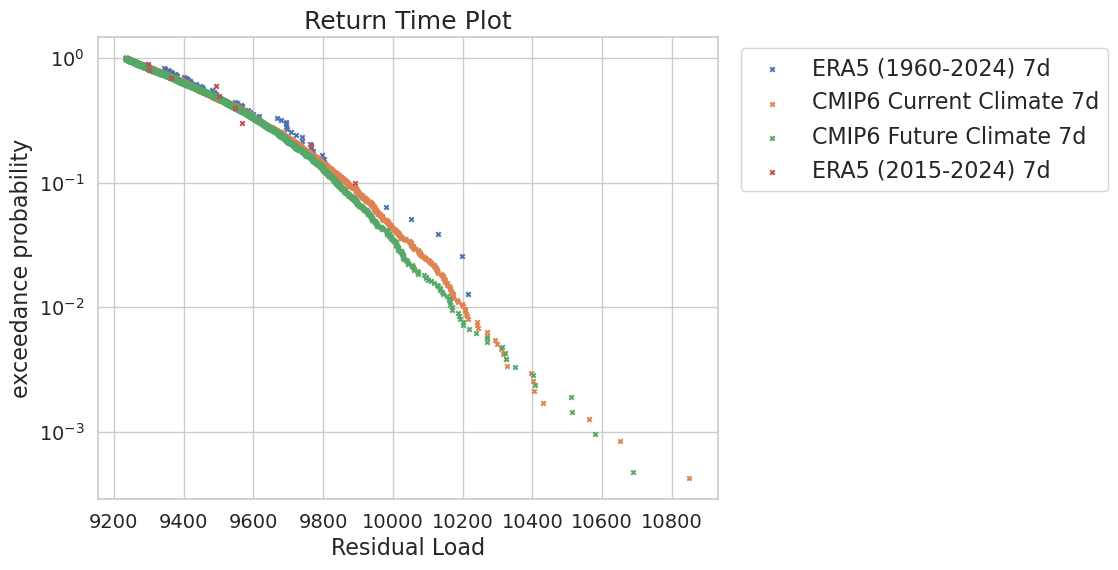

In [68]:
# This is only for the 1d values (but correct otherwise)

RLs = [LEE_7_ERA5['RL_cumulative'], LEE_7_CMIP['RL_cumulative'], LEE_7_fut['RL_cumulative'], LEE_7_ERA5_15_24['RL_cumulative']]
labels = ['ERA5 (1960-2024) 7d', 'CMIP6 Current Climate 7d', 'CMIP6 Future Climate 7d', 'ERA5 (2015-2024) 7d']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
#        res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
#           'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # event rate
    if ('ERA5' in label) and ('15' in label):
        n_years = 10  # ERA5 covers 2015-2024 for this subset
    elif 'ERA5' in label:
        n_years = 65  # ERA5 covers 1960-2024
    else:
        n_years = 10 * 192  # 10 years for each of the 192 runs
    
    lambda_ = N / n_years
    
    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()


# # Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()

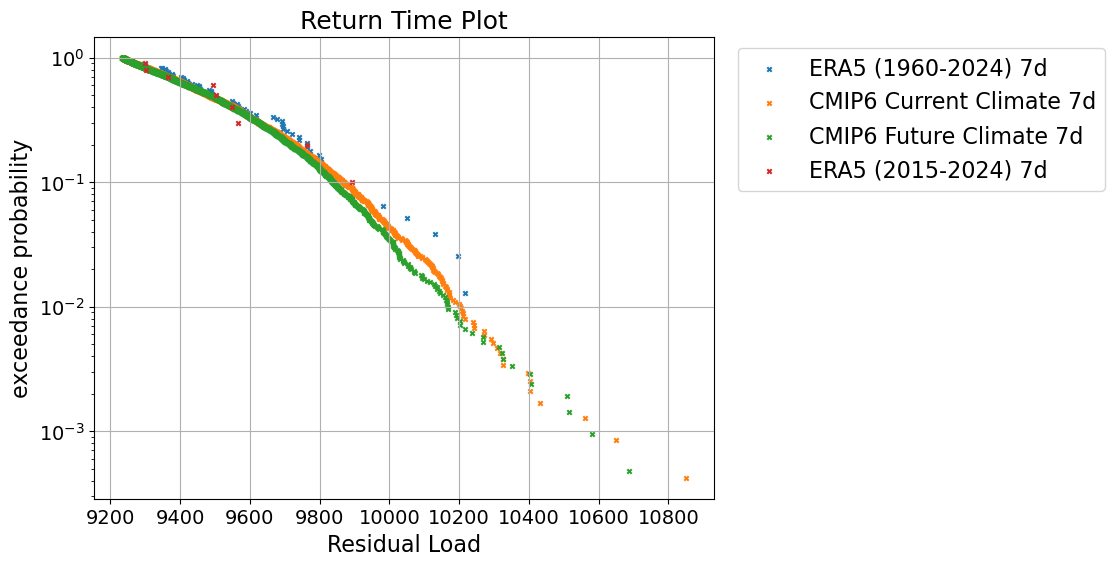

In [43]:
# This is only for the 1d values (but correct otherwise)

RLs = [LEE_7_ERA5['RL_cumulative'], LEE_7_CMIP['RL_cumulative'], LEE_7_fut['RL_cumulative'], LEE_7_ERA5_15_24['RL_cumulative']]
labels = ['ERA5 (1960-2024) 7d', 'CMIP6 Current Climate 7d', 'CMIP6 Future Climate 7d', 'ERA5 (2015-2024) 7d']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
#        res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
#           'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # event rate
    if ('ERA5' in label) and ('15' in label):
        n_years = 10  # ERA5 covers 2015-2024 for this subset
    elif 'ERA5' in label:
        n_years = 65  # ERA5 covers 1960-2024
    else:
        n_years = 10 * 192  # 10 years for each of the 192 runs
    
    lambda_ = N / n_years
    
    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()


# # Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()

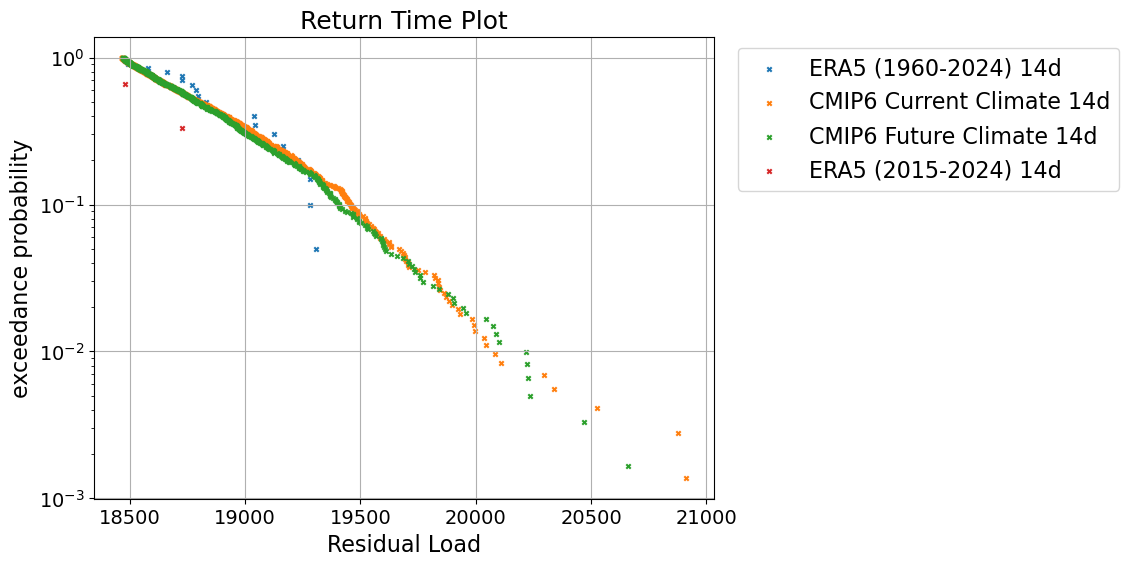

In [44]:
# This is only for the 1d values (but correct otherwise)

RLs = [LEE_14_ERA5['RL_cumulative'], LEE_14_CMIP['RL_cumulative'], LEE_14_fut['RL_cumulative'], LEE_14_ERA5_15_24['RL_cumulative']]
labels = ['ERA5 (1960-2024) 14d', 'CMIP6 Current Climate 14d', 'CMIP6 Future Climate 14d', 'ERA5 (2015-2024) 14d']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
#        res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
#           'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']

# RLs = [# res_load_ERA5, 
#        res_load_curr_clim_1d, res_load_fut_1d, res_load_era5_15_24_1d,
#        res_load_ERA5_2015_2019, res_load_ERA5_2020_2024]
# labels = [#'ERA5 (1960-2024)', 
#           'CMIP6 Current Climate', 'CMIP6 Future Climate', 'ERA5 (2015-2024)',
#           'ERA5 (2015-2019)', 'ERA5 (2020-2024)']

# RLs = [res_load_era5_15_24]
# labels = ['ERA5 (2015-2024)']
# Plot
plt.figure(figsize=(8,6))


for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort ascending
    x = np.sort(extremes)

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # event rate
    if ('ERA5' in label) and ('15' in label):
        n_years = 10  # ERA5 covers 2015-2024 for this subset
    elif 'ERA5' in label:
        n_years = 65  # ERA5 covers 1960-2024
    else:
        n_years = 10 * 192  # 10 years for each of the 192 runs
    
    lambda_ = N / n_years
    
    # Return period
    # T = (N + 1) / (N + 1 - m)
    T = (1 - (m/(N+1)))  # equivalent, more direct formula
        


    plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
plt.yscale('log')
# plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.xlim(np.float64(1470.138650687668), np.float64(1480.223514139268)*1.01)

# plt.ylim(1e-4, 1e-1)
plt.ylabel('exceedance probability')
plt.xlabel('Residual Load')
plt.title('Return Time Plot')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.show()


# # Plot
# plt.figure(figsize=(8,6))


# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort descending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     # T = (1 - (m/(N+1)))  # equivalent, more direct formula
#     # Return period
#     T = (N + 1) / m
        


#     plt.scatter(x, T, marker='x', s=10, label=label) # Marker = cross, size = 1
# plt.vlines(np.float64(1319.138650687668), ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
# plt.yscale('log')
# # plt.xscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylabel('Return Period')
# plt.xlabel('Residual Load')
# plt.title('Return Time Plot')
# plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
# plt.grid(True)
# plt.show()